<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v3-acceptance/notebooks/24_h1_h8_acceptance_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 24 — H1/H8 Acceptance Transfer

## Research question

Does the long-horizon decoder-fidelity advantage of H8 training translate into
higher speculative acceptance and fewer target-model verification rounds?

## Compared models

- H1: jointly trained NextLat with `mtp_horizon = 1`
- H8: jointly trained NextLat with `mtp_horizon = 8`

Both models use the same architecture, training seed, dataset, optimizer,
training-token budget, and checkpoint iteration.

## Evaluation domains

1. TinyStories validation
2. WikiText-103 test OOD chunks

## Primary metrics

- empirical acceptance by draft position
- acceptance probability by draft position
- mean accepted prefix
- emitted tokens per verification round
- verification rounds per 100 generated tokens

## Scope

The first stage measures acceptance transfer under a matched experimental
protocol. End-to-end latency is measured only after correctness and acceptance
have been validated.

In [1]:
import sys
import torch
import subprocess

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory GB:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
    )
    print("BF16 supported:", torch.cuda.is_bf16_supported())

print("\nnvidia-smi:")
result = subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total,memory.free",
        "--format=csv,noheader",
    ],
    capture_output=True,
    text=True,
)
print(result.stdout.strip())

assert torch.cuda.is_available()
print("\nNotebook 24 environment check passed.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
GPU memory GB: 22.03
BF16 supported: True

nvidia-smi:
NVIDIA L4, 23034 MiB, 22561 MiB

Notebook 24 environment check passed.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import os
import random
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path("/content/drive/MyDrive/ma2288_nextlat")
V3_DIR = PROJECT_DIR / "research_v3"

CHECKPOINT_DIR = V3_DIR / "checkpoints"
DATA_DIR = V3_DIR / "data"
RESULTS_DIR = V3_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
METADATA_DIR = RESULTS_DIR / "metadata"

for directory in [
    DATA_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    METADATA_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Research V3 directory:", V3_DIR)
print("Project exists:", PROJECT_DIR.exists())
print("Research V3 exists:", V3_DIR.exists())

assert PROJECT_DIR.exists()
assert V3_DIR.exists()

print("\nCell 3 project paths passed.")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/ma2288_nextlat
Research V3 directory: /content/drive/MyDrive/ma2288_nextlat/research_v3
Project exists: True
Research V3 exists: True

Cell 3 project paths passed.


In [4]:
H1_CHECKPOINT = (
    CHECKPOINT_DIR
    / "nextlat_pilot_5000_seed42"
    / "NextLat_Scaled_5000Step_Seed42-seed42"
    / "ckpt_iter_5000_2.0028.pt"
)

H8_CHECKPOINT = (
    CHECKPOINT_DIR
    / "nextlat_h8_pilot_5000_seed42"
    / "NextLat_H8_5000Step_Seed42-seed42"
    / "ckpt_iter_5000_2.3431.pt"
)

H1_CONFIG = H1_CHECKPOINT.parent / "materialized_config.yaml"
H8_CONFIG = H8_CHECKPOINT.parent / "materialized_config.yaml"

WIKITEXT_TOKENS = (
    DATA_DIR
    / "wikitext103_test_ood_chunks_seed42.pt"
)

WIKITEXT_CHUNK_METADATA = (
    TABLES_DIR
    / "wikitext103_test_ood_chunk_metadata_seed42.csv"
)

paths_to_check = {
    "H1 checkpoint": H1_CHECKPOINT,
    "H8 checkpoint": H8_CHECKPOINT,
    "H1 materialized config": H1_CONFIG,
    "H8 materialized config": H8_CONFIG,
    "WikiText token cache": WIKITEXT_TOKENS,
    "WikiText chunk metadata": WIKITEXT_CHUNK_METADATA,
}

print("=" * 110)
print("NOTEBOOK 24 INPUT ARTIFACTS")
print("=" * 110)

for name, path in paths_to_check.items():
    exists = path.exists()
    size_mb = path.stat().st_size / 1024**2 if exists else None

    print(f"\n{name}:")
    print(path)
    print("Exists:", exists)

    if exists:
        print("Size MB:", round(size_mb, 3))

assert H1_CHECKPOINT.exists()
assert H8_CHECKPOINT.exists()
assert H1_CONFIG.exists()
assert H8_CONFIG.exists()
assert WIKITEXT_TOKENS.exists()
assert WIKITEXT_CHUNK_METADATA.exists()

h1_raw_checkpoint = torch.load(
    H1_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)
h8_raw_checkpoint = torch.load(
    H8_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

print("\n" + "=" * 110)
print("CHECKPOINT SUMMARY")
print("=" * 110)
print("H1 training steps:", h1_raw_checkpoint.get("training_steps"))
print("H8 training steps:", h8_raw_checkpoint.get("training_steps"))
print("H1 state tensors:", len(h1_raw_checkpoint["model"]))
print("H8 state tensors:", len(h8_raw_checkpoint["model"]))

assert h1_raw_checkpoint["training_steps"] == 5000
assert h8_raw_checkpoint["training_steps"] == 5000
assert set(h1_raw_checkpoint["model"]) == set(h8_raw_checkpoint["model"])

print("\nCell 4 checkpoint validation passed.")

NOTEBOOK 24 INPUT ARTIFACTS

H1 checkpoint:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_2.0028.pt
Exists: True
Size MB: 50.743

H8 checkpoint:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42/NextLat_H8_5000Step_Seed42-seed42/ckpt_iter_5000_2.3431.pt
Exists: True
Size MB: 50.743

H1 materialized config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/materialized_config.yaml
Exists: True
Size MB: 0.002

H8 materialized config:
/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42/NextLat_H8_5000Step_Seed42-seed42/materialized_config.yaml
Exists: True
Size MB: 0.002

WikiText token cache:
/content/drive/MyDrive/ma2288_nextlat/research_v3/data/wikitext103_test_ood_chunks_seed42.pt
Exists: True
Size MB: 0.936

WikiText chunk metadata:
/con

In [5]:
OFFICIAL_REPO = Path("/content/NextLat")
OFFICIAL_COMMIT = "3770be6009cea2b3c455a9ce7f2ca88b504bb955"

if not OFFICIAL_REPO.exists():
    clone_result = subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/JaydenTeoh/NextLat.git",
            str(OFFICIAL_REPO),
        ],
        capture_output=True,
        text=True,
    )

    print("Clone return code:", clone_result.returncode)

    if clone_result.stdout:
        print("\nSTDOUT:")
        print(clone_result.stdout)

    if clone_result.stderr:
        print("\nSTDERR:")
        print(clone_result.stderr[-3000:])

    assert clone_result.returncode == 0

checkout_result = subprocess.run(
    ["git", "checkout", OFFICIAL_COMMIT],
    cwd=OFFICIAL_REPO,
    capture_output=True,
    text=True,
)

head_result = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=OFFICIAL_REPO,
    capture_output=True,
    text=True,
    check=True,
)

loaded_commit = head_result.stdout.strip()

print("=" * 100)
print("OFFICIAL NEXTLAT SOURCE")
print("=" * 100)
print("Repository:", OFFICIAL_REPO)
print("Expected commit:", OFFICIAL_COMMIT)
print("Loaded commit:", loaded_commit)
print("Checkout return code:", checkout_result.returncode)

assert checkout_result.returncode == 0
assert loaded_commit == OFFICIAL_COMMIT

os.chdir(OFFICIAL_REPO)

if str(OFFICIAL_REPO) not in sys.path:
    sys.path.insert(0, str(OFFICIAL_REPO))

print("\nCell 5 official source validation passed.")

Clone return code: 0

STDERR:
Cloning into '/content/NextLat'...

OFFICIAL NEXTLAT SOURCE
Repository: /content/NextLat
Expected commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Loaded commit: 3770be6009cea2b3c455a9ce7f2ca88b504bb955
Checkout return code: 0

Cell 5 official source validation passed.


In [6]:
import importlib.util
import subprocess
import sys

dependency_map = {
    "lightning": "lightning==2.6.5",
    "liger_kernel": "liger-kernel==0.8.0",
}

missing_packages = []

print("=" * 90)
print("DEPENDENCY CHECK")
print("=" * 90)

for module_name, package_specification in dependency_map.items():
    available = importlib.util.find_spec(module_name) is not None
    print(
        f"{module_name:<20}",
        "AVAILABLE" if available else "MISSING",
    )

    if not available:
        missing_packages.append(package_specification)

print("\nPackages to install:", missing_packages)

if missing_packages:
    install_result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *missing_packages,
        ],
        capture_output=True,
        text=True,
    )

    print("Installation return code:", install_result.returncode)

    if install_result.stdout:
        print("\nSTDOUT:")
        print(install_result.stdout[-3000:])

    if install_result.stderr:
        print("\nSTDERR:")
        print(install_result.stderr[-3000:])

    assert install_result.returncode == 0

print("\nCell 6 dependency installation completed.")

DEPENDENCY CHECK
lightning            MISSING
liger_kernel         MISSING

Packages to install: ['lightning==2.6.5', 'liger-kernel==0.8.0']
Installation return code: 0

STDOUT:
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 56.3 MB/s eta 0:00:00


Cell 6 dependency installation completed.


In [7]:
import importlib
import importlib.metadata

packages_to_report = [
    ("torch", "torch"),
    ("lightning", "lightning"),
    ("liger-kernel", "liger-kernel"),
    ("omegaconf", "omegaconf"),
    ("datasets", "datasets"),
    ("transformers", "transformers"),
    ("wandb", "wandb"),
]

print("=" * 100)
print("PACKAGE VERSIONS")
print("=" * 100)

for display_name, distribution_name in packages_to_report:
    try:
        version = importlib.metadata.version(distribution_name)
    except importlib.metadata.PackageNotFoundError:
        version = "NOT INSTALLED"

    print(f"{display_name:<20} {version}")

modules_to_test = [
    "data.tinystories",
    "models.model_base",
    "models.model_gpt",
    "models.model_nextlat",
    "core_train",
]

print("\n" + "=" * 100)
print("OFFICIAL IMPORT SMOKE TEST")
print("=" * 100)

for module_name in modules_to_test:
    importlib.import_module(module_name)
    print(f"{module_name:<32} PASS")

print("\nAll official imports passed.")

PACKAGE VERSIONS
torch                2.11.0+cu128
lightning            2.6.5
liger-kernel         0.8.0
omegaconf            2.3.1
datasets             4.0.0
transformers         5.13.1
wandb                0.28.0

OFFICIAL IMPORT SMOKE TEST
data.tinystories                 PASS
models.model_base                PASS
models.model_gpt                 PASS
models.model_nextlat             PASS
core_train                       PASS

All official imports passed.


In [8]:
from pathlib import Path
import subprocess

SEARCH_PATTERNS = [
    "generate",
    "sampling_mode",
    "mtp_horizon",
    "dynamics_model",
    "accept",
    "speculative",
    "return_hidden_states",
]

SEARCH_ROOTS = [
    OFFICIAL_REPO / "eval",
    OFFICIAL_REPO / "models",
    OFFICIAL_REPO / "utils",
    OFFICIAL_REPO / "scripts",
]

print("=" * 120)
print("OFFICIAL GENERATION / SPECULATION SOURCE AUDIT")
print("=" * 120)

for pattern in SEARCH_PATTERNS:
    print("\n" + "-" * 120)
    print("PATTERN:", pattern)
    print("-" * 120)

    existing_roots = [
        str(path)
        for path in SEARCH_ROOTS
        if path.exists()
    ]

    search_result = subprocess.run(
        [
            "grep",
            "-RIn",
            "--include=*.py",
            pattern,
            *existing_roots,
        ],
        capture_output=True,
        text=True,
    )

    matching_lines = search_result.stdout.strip().splitlines()

    if not matching_lines:
        print("No matches.")
    else:
        for line in matching_lines[:80]:
            print(line)

        if len(matching_lines) > 80:
            print(
                f"... truncated: {len(matching_lines) - 80} additional matches"
            )

print("\nCell 8 source search completed.")

OFFICIAL GENERATION / SPECULATION SOURCE AUDIT

------------------------------------------------------------------------------------------------------------------------
PATTERN: generate
------------------------------------------------------------------------------------------------------------------------
/content/NextLat/eval/eval_speculative_checkpoints.py:115:        help="Number of new tokens to generate per sample.",
/content/NextLat/eval/eval_speculative_checkpoints.py:602:        _ = model_wrapper.generate(
/content/NextLat/eval/lm-eval.py:83:    Supports GPT/NextLat/JTP/MTP-like wrappers with `model(...)` + `generate(...)`.
/content/NextLat/eval/lm-eval.py:328:    def generate_until(self, requests):
/content/NextLat/eval/lm-eval.py:333:            print(f"[rank {self._rank}] lm-eval generate_until start: {total} requests")
/content/NextLat/eval/lm-eval.py:365:            generated = self.model_wrapper.generate(
/content/NextLat/eval/lm-eval.py:371:            new_tokens = gene

In [9]:
import inspect
from models.model_nextlat import (
    NextLat,
    NextLatConfig,
    NextLatDynamicsModel,
    NextLatTransformer,
)

print("=" * 120)
print("OFFICIAL EVALUATION FILES")
print("=" * 120)

evaluation_files = sorted(
    path.relative_to(OFFICIAL_REPO)
    for path in OFFICIAL_REPO.rglob("*.py")
    if (
        "eval" in path.parts
        or "sample" in path.name.lower()
        or "generate" in path.name.lower()
    )
)

for index, path in enumerate(evaluation_files):
    print(f"[{index:02d}] {path}")

print("\n" + "=" * 120)
print("NEXTLAT METHOD SIGNATURES")
print("=" * 120)

classes_to_inspect = [
    NextLat,
    NextLatTransformer,
    NextLatDynamicsModel,
]

for class_object in classes_to_inspect:
    print(f"\nClass: {class_object.__name__}")
    print("Constructor:", inspect.signature(class_object))

    for method_name in [
        "forward",
        "generate",
        "sample",
        "evaluate",
        "_nextlat_loss_function",
    ]:
        if hasattr(class_object, method_name):
            method = getattr(class_object, method_name)
            print(
                f"{method_name}:",
                inspect.signature(method),
            )

print("\n" + "=" * 120)
print("NEXTLAT PUBLIC ATTRIBUTES")
print("=" * 120)

public_attributes = [
    name
    for name in dir(NextLat)
    if not name.startswith("__")
]

for name in public_attributes:
    lowered = name.lower()

    if any(
        keyword in lowered
        for keyword in [
            "gener",
            "sampl",
            "forward",
            "eval",
            "loss",
            "model",
        ]
    ):
        print(name)

print("\nCell 9 API audit completed.")

OFFICIAL EVALUATION FILES
[00] data/countdown/generate.py
[01] data/manhattan/generate_manhattan_trajectories.py
[02] eval/eval_checkpoints.py
[03] eval/eval_speculative_checkpoints.py
[04] eval/lm-eval.py

NEXTLAT METHOD SIGNATURES

Class: NextLat
Constructor: (config: models.model_nextlat.NextLatConfig)
generate: (self, idx: torch.Tensor, max_new_tokens: int, temperature: float = 1.0, top_k: Optional[int] = None) -> torch.Tensor
_nextlat_loss_function: (self, pred_h_t_next: torch.Tensor, h_t_next: torch.Tensor, target_tokens: torch.Tensor, teacher_logits: torch.Tensor, token_pred_mask: torch.Tensor, mse_mask: torch.Tensor)

Class: NextLatTransformer
Constructor: (config: models.model_nextlat.NextLatConfig)
forward: (self, batch: torch.Tensor, mask: Optional[torch.Tensor] = None, targets: Optional[torch.Tensor] = None, return_hidden_states: bool = False) -> torch.Tensor

Class: NextLatDynamicsModel
Constructor: (config)
forward: (self, current_states: torch.Tensor, next_token_embeds: 

In [10]:
import inspect

from models.model_nextlat import NextLat
from models.model_speculative import SpeculativeModel

print("=" * 120)
print("NEXTLAT.SPECULATIVE_PROPOSE")
print("=" * 120)
print(inspect.getsource(NextLat.speculative_propose))

print("\n" + "=" * 120)
print("SPECULATIVE MODEL INTERFACE")
print("=" * 120)
print(inspect.getsource(SpeculativeModel))

NEXTLAT.SPECULATIVE_PROPOSE
    @torch.inference_mode()
    def speculative_propose(
        self,
        seq: torch.Tensor,
        steps_to_propose: int,
        temperature: float,
        top_k: Optional[int],
        top_p: Optional[float],
    ) -> Tuple[torch.Tensor, List[torch.Tensor]]:
        core = self._unwrap_module()
        _, hidden_states = core(seq, return_hidden_states=True)
        state = hidden_states[:, -1, :]
        drafted: List[torch.Tensor] = []
        q_probs_steps: List[torch.Tensor] = []

        for _ in range(steps_to_propose):
            logits = core.lm_head(state)
            q_probs = normalize_logits(
                logits, temperature=temperature, top_k=top_k, top_p=top_p
            )
            tok = sample_from_probs(q_probs)
            drafted.append(tok)
            q_probs_steps.append(q_probs)
            next_token_emb = core.token_embedding(tok).squeeze(1)
            state = core.dynamics_model(state, next_token_emb)

        retur

In [11]:
import inspect

from utils.speculative_sampling import (
    speculative_decode_v2,
    normalize_logits,
    sample_from_probs,
)

print("=" * 120)
print("SPECULATIVE_DECODE_V2")
print("=" * 120)
print(inspect.getsource(speculative_decode_v2))

print("\n" + "=" * 120)
print("NORMALIZE_LOGITS")
print("=" * 120)
print(inspect.getsource(normalize_logits))

print("\n" + "=" * 120)
print("SAMPLE_FROM_PROBS")
print("=" * 120)
print(inspect.getsource(sample_from_probs))

SPECULATIVE_DECODE_V2
@torch.inference_mode()
def speculative_decode_v2(
    idx: torch.Tensor,
    max_new_tokens: int,
    gamma: int,
    propose_fn: Callable[[torch.Tensor, int], Tuple[torch.Tensor, List[torch.Tensor]]],
    target_probs_fn: Callable[
        [torch.Tensor, torch.Tensor], Tuple[torch.Tensor, torch.Tensor]
    ],
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Speculative decoding loop.

    Args:
        idx: input prefix ids [B, T].
        max_new_tokens: number of new tokens to generate.
        gamma: drafted tokens per speculative round.
        propose_fn: returns (draft_tokens [1, S], q_probs_steps list len=S each [1, V]).
        target_probs_fn: returns (p_probs_steps [1, S, V], p_next_probs [1, V]).
    """
    assert idx.dim() == 2, "idx must be rank-2 [batch, seq]"
    assert gamma >= 1, "gamma must be >= 1"

    device = idx.device
    generated = []
    total_accepted = 0
    total_proposed = 0
    total_proposed_excl_pos1_all_drafted = 0
    

In [12]:
EVAL_SPECULATIVE_PATH = (
    OFFICIAL_REPO
    / "eval"
    / "eval_speculative_checkpoints.py"
)

source_lines = EVAL_SPECULATIVE_PATH.read_text().splitlines()

ranges_to_print = [
    (580, 735, "DATASET SPECULATIVE BENCHMARK"),
    (885, 935, "MODEL / PROPOSER / TARGET CONNECTION"),
]

for start_line, end_line, title in ranges_to_print:
    print("=" * 120)
    print(title)
    print("=" * 120)

    for line_number in range(start_line, end_line + 1):
        if line_number <= len(source_lines):
            print(
                f"{line_number:04d}: "
                f"{source_lines[line_number - 1]}"
            )

    print()

DATASET SPECULATIVE BENCHMARK
0580:             empty_result[f"acceptance_rate_pos_{pos}"] = 0.0
0581:         return empty_result
0582: 
0583:     ar_seconds = 0.0
0584:     spec_seconds = 0.0
0585:     total_new_tokens = float(total_samples * max_new_tokens)
0586:     agg_stats = {
0587:         "accepted_tokens": 0.0,
0588:         "proposed_tokens": 0.0,
0589:         "rejected_tokens": 0.0,
0590:         "target_samples": 0.0,
0591:         "resamples": 0.0,
0592:         "accepted_tokens_pos2plus": 0.0,
0593:         "proposed_tokens_pos2plus_all_drafted": 0.0,
0594:     }
0595: 
0596:     for prompt in eval_prompts:
0597:         idx = torch.tensor([prompt], dtype=torch.long, device=device)
0598: 
0599:         if device.type == "cuda":
0600:             torch.cuda.synchronize(device)
0601:         t0 = time.perf_counter()
0602:         _ = model_wrapper.generate(
0603:             idx.clone(),
0604:             max_new_tokens=max_new_tokens,
0605:             temperature=temper

In [13]:
import inspect

from core_train import initialize_model

print("=" * 120)
print("INITIALIZE_MODEL SIGNATURE")
print("=" * 120)
print(inspect.signature(initialize_model))

print("\n" + "=" * 120)
print("INITIALIZE_MODEL SOURCE")
print("=" * 120)
print(inspect.getsource(initialize_model))

INITIALIZE_MODEL SIGNATURE
(fabric: lightning.fabric.fabric.Fabric, config, tokenizer, initialize_optimizer=True, checkpoint_path: Optional[str] = None)

INITIALIZE_MODEL SOURCE
def initialize_model(
    fabric: L.Fabric,
    config,
    tokenizer,
    initialize_optimizer=True,
    checkpoint_path: Optional[str] = None,
):
    fabric.print(f"Initializing model with config: {config}")

    if config.use_bst:
        ModelClass = BST
        ModelConfigClass = BSTConfig
        single_gap_modes = ["next_token", "eos"]
        assert (
            config.model.bst_single_gap_prediction_mode in single_gap_modes
        ), f"BST single gap mode must be one of {single_gap_modes}"
    elif config.use_nextlat:
        ModelClass = NextLat
        ModelConfigClass = NextLatConfig
    elif config.use_mtp_gloeckle:
        ModelClass = MTPGloeckle
        ModelConfigClass = MTPGloeckleConfig
    elif config.use_mtp_jtp:
        ModelClass = JTP
        ModelConfigClass = MTPJTPConfig
    else:
 

In [15]:
from collections.abc import Mapping
from omegaconf import OmegaConf

DEFAULT_CONFIG_PATH = OFFICIAL_REPO / "defaults.yaml"

default_config = OmegaConf.load(DEFAULT_CONFIG_PATH)
h1_user_config = OmegaConf.load(H1_CONFIG)
h8_user_config = OmegaConf.load(H8_CONFIG)

h1_config = OmegaConf.merge(
    default_config,
    h1_user_config,
)
h8_config = OmegaConf.merge(
    default_config,
    h8_user_config,
)

# Convert DictConfig/ListConfig into ordinary Python containers.
h1_container = OmegaConf.to_container(
    h1_config,
    resolve=True,
)
h8_container = OmegaConf.to_container(
    h8_config,
    resolve=True,
)

def flatten_config(value, prefix=""):
    """
    Recursively flatten dictionaries.

    Lists are preserved as complete values because list positions are not
    independent experimental configuration fields.
    """
    flattened = {}

    if isinstance(value, Mapping):
        for key, child_value in value.items():
            full_key = (
                f"{prefix}.{key}"
                if prefix
                else str(key)
            )

            if isinstance(child_value, Mapping):
                flattened.update(
                    flatten_config(
                        child_value,
                        prefix=full_key,
                    )
                )
            else:
                flattened[full_key] = child_value
    else:
        flattened[prefix] = value

    return flattened

h1_flat = flatten_config(h1_container)
h8_flat = flatten_config(h8_container)

all_fields = sorted(
    set(h1_flat.keys())
    | set(h8_flat.keys())
)

config_differences = []

for field in all_fields:
    h1_value = h1_flat.get(field)
    h8_value = h8_flat.get(field)

    if h1_value != h8_value:
        config_differences.append(
            {
                "field": field,
                "h1": repr(h1_value),
                "h8": repr(h8_value),
            }
        )

config_difference_df = pd.DataFrame(
    config_differences,
    columns=["field", "h1", "h8"],
)

print("=" * 120)
print("FULL H1 VS H8 CONFIG DIFFERENCES")
print("=" * 120)

if len(config_difference_df) == 0:
    print("No differences found.")
else:
    print(
        config_difference_df.to_string(
            index=False,
        )
    )

allowed_differences = {
    "model.mtp_horizon",
    "trainer.experiment_name",
    "trainer.out_dir",
}

observed_differences = set(
    config_difference_df["field"].tolist()
)

print("\nObserved differences:")
print(sorted(observed_differences))

print("\nAllowed differences:")
print(sorted(allowed_differences))

unexpected_differences = (
    observed_differences
    - allowed_differences
)

missing_expected_differences = (
    allowed_differences
    - observed_differences
)

print("\nUnexpected differences:")
print(sorted(unexpected_differences))

print("\nMissing expected differences:")
print(sorted(missing_expected_differences))

assert not unexpected_differences
assert observed_differences == allowed_differences

print("\nCell 14 matched configuration passed.")

FULL H1 VS H8 CONFIG DIFFERENCES
                  field                                                                                        h1                                                                                           h8
      model.mtp_horizon                                                                                         1                                                                                            8
trainer.experiment_name                                                   'NextLat_Scaled_5000Step_Seed42-seed42'                                                          'NextLat_H8_5000Step_Seed42-seed42'
        trainer.out_dir '/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42' '/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42'

Observed differences:
['model.mtp_horizon', 'trainer.experiment_name', 'trainer.out_dir']

Allowed differences:
['model.mtp_horizon', 'tra

In [16]:
import lightning as L
from transformers import PreTrainedTokenizerFast

DEVICE = torch.device("cuda")

fabric = L.Fabric(
    accelerator="cuda",
    devices=1,
    precision="bf16-mixed",
)
fabric.launch()

TOKENIZER_PATH = (
    OFFICIAL_REPO
    / "data"
    / "tinystories"
    / "tokenizer.json"
)

tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=str(TOKENIZER_PATH),
    eos_token="<|eos|>",
    pad_token="<|pad|>",
)

print("=" * 100)
print("FABRIC / TOKENIZER")
print("=" * 100)
print("Fabric device:", fabric.device)
print("Fabric world size:", fabric.world_size)
print("Tokenizer vocabulary:", len(tokenizer))
print("EOS token:", tokenizer.eos_token)
print("EOS ID:", tokenizer.eos_token_id)
print("PAD token:", tokenizer.pad_token)
print("PAD ID:", tokenizer.pad_token_id)

assert fabric.world_size == 1
assert len(tokenizer) == 1000
assert tokenizer.eos_token_id == 1
assert tokenizer.pad_token_id == 0

print("\nCell 15 Fabric/tokenizer initialization passed.")

INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


FABRIC / TOKENIZER
Fabric device: cuda:0
Fabric world size: 1
Tokenizer vocabulary: 1000
EOS token: <|eos|>
EOS ID: 1
PAD token: <|pad|>
PAD ID: 0

Cell 15 Fabric/tokenizer initialization passed.


In [17]:
from models.model_speculative import SpeculativeModel

h1_wrapper = initialize_model(
    fabric=fabric,
    config=h1_config,
    tokenizer=tokenizer,
    initialize_optimizer=False,
    checkpoint_path=str(H1_CHECKPOINT),
)

h8_wrapper = initialize_model(
    fabric=fabric,
    config=h8_config,
    tokenizer=tokenizer,
    initialize_optimizer=False,
    checkpoint_path=str(H8_CHECKPOINT),
)

h1_wrapper.eval()
h8_wrapper.eval()

print("=" * 110)
print("OFFICIAL H1/H8 MODEL INITIALIZATION")
print("=" * 110)

print("H1 wrapper type:", type(h1_wrapper))
print("H8 wrapper type:", type(h8_wrapper))
print("H1 implements SpeculativeModel:", isinstance(h1_wrapper, SpeculativeModel))
print("H8 implements SpeculativeModel:", isinstance(h8_wrapper, SpeculativeModel))
print("H1 training horizon:", h1_wrapper.config.mtp_horizon)
print("H8 training horizon:", h8_wrapper.config.mtp_horizon)

h1_core = h1_wrapper._unwrap_module()
h8_core = h8_wrapper._unwrap_module()

print("\nH1 core type:", type(h1_core))
print("H8 core type:", type(h8_core))
print(
    "H1 parameter count:",
    sum(parameter.numel() for parameter in h1_core.parameters()),
)
print(
    "H8 parameter count:",
    sum(parameter.numel() for parameter in h8_core.parameters()),
)
print(
    "H1 parameter device:",
    next(h1_core.parameters()).device,
)
print(
    "H8 parameter device:",
    next(h8_core.parameters()).device,
)

assert isinstance(h1_wrapper, SpeculativeModel)
assert isinstance(h8_wrapper, SpeculativeModel)
assert h1_wrapper.config.mtp_horizon == 1
assert h8_wrapper.config.mtp_horizon == 8
assert next(h1_core.parameters()).is_cuda
assert next(h8_core.parameters()).is_cuda

print("\nCell 16 official H1/H8 initialization passed.")

Initializing model with config: {'use_bst': False, 'use_nextlat': True, 'use_mtp_gloeckle': False, 'use_mtp_jtp': False, 'seed': 42, 'trainer': {'train_batches': 5000, 'val_batches': 50, 'val_only': False, 'log_interval': 50, 'val_interval': 500, 'save_last_checkpoint': True, 'save_best_checkpoint': True, 'always_save_checkpoint': False, 'save_recovery_checkpoint': 1000, 'keep_checkpoint_steps': [1000, 2500, 5000], 'out_dir': '/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42', 'init_from': 'scratch', 'log_to_file': True, 'log_to_wandb': False, 'wandb_project': 'tinystories', 'deterministic': False, 'compile': False, 'use_fused_kernels': False, 'garbage_collect': -1, 'sampling_mode': 'AR', 'speculative_gamma': 4, 'top_p': None, 'train_probe': False, 'wandb_tags': [], 'val_printsamples': False, 'test_interval': 1000000, 'experiment_name': 'NextLat_Scaled_5000Step_Seed42-seed42'}, 'data': {'dataset': 'tinystories', 'effective_batch_size': 64, 'gradie

In [18]:
from utils.speculative_sampling import speculative_decode_v2

BOUNDARY_PREFIX = torch.tensor(
    [[430, 2, 696, 223, 258, 355, 270, 393]],
    dtype=torch.long,
    device=DEVICE,
)

boundary_rows = []

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    propose_fn = model_wrapper.build_speculative_propose_fn(
        temperature=1.0,
        top_k=1,
        top_p=None,
    )

    target_probs_fn = model_wrapper.build_speculative_target_probs_fn(
        temperature=1.0,
        top_k=1,
        top_p=None,
    )

    for gamma in [1, 2, 4, 8]:
        for requested_new_tokens in [1, 2, 3, 4, 8, 9]:
            torch.manual_seed(SEED)
            torch.cuda.manual_seed_all(SEED)

            output, stats = speculative_decode_v2(
                idx=BOUNDARY_PREFIX.clone(),
                max_new_tokens=requested_new_tokens,
                gamma=gamma,
                propose_fn=propose_fn,
                target_probs_fn=target_probs_fn,
            )

            actual_new_tokens = (
                output.size(1)
                - BOUNDARY_PREFIX.size(1)
            )

            boundary_rows.append(
                {
                    "model": method_name,
                    "gamma": gamma,
                    "requested_new_tokens": requested_new_tokens,
                    "actual_new_tokens": actual_new_tokens,
                    "length_difference": (
                        actual_new_tokens
                        - requested_new_tokens
                    ),
                    "accepted_tokens": stats["accepted_tokens"],
                    "target_samples": stats["target_samples"],
                    "resamples": stats["resamples"],
                }
            )

boundary_df = pd.DataFrame(boundary_rows)

print("=" * 130)
print("OFFICIAL VERIFIER LENGTH-BOUNDARY AUDIT")
print("=" * 130)
print(boundary_df.to_string(index=False))

incorrect_length_df = boundary_df[
    boundary_df["length_difference"] != 0
].copy()

print("\n" + "=" * 130)
print("INCORRECT-LENGTH CASES")
print("=" * 130)

if len(incorrect_length_df) == 0:
    print("None")
else:
    print(incorrect_length_df.to_string(index=False))

print(
    "\nIncorrect-length cases:",
    len(incorrect_length_df),
    "/",
    len(boundary_df),
)

print("\nCell 17 official verifier boundary audit completed.")

OFFICIAL VERIFIER LENGTH-BOUNDARY AUDIT
model  gamma  requested_new_tokens  actual_new_tokens  length_difference  accepted_tokens  target_samples  resamples
   H1      1                     1                  2                  1              1.0             1.0        0.0
   H1      1                     2                  2                  0              1.0             1.0        0.0
   H1      1                     3                  4                  1              2.0             2.0        0.0
   H1      1                     4                  4                  0              2.0             2.0        0.0
   H1      1                     8                  8                  0              4.0             4.0        0.0
   H1      1                     9                 10                  1              5.0             5.0        0.0
   H1      2                     1                  2                  1              1.0             1.0        0.0
   H1      2            

In [19]:
from typing import Callable, Dict, List, Optional, Tuple

import torch

from utils.speculative_sampling import sample_from_probs


@torch.inference_mode()
def speculative_decode_exact_length(
    idx: torch.Tensor,
    max_new_tokens: int,
    gamma: int,
    propose_fn: Callable,
    target_probs_fn: Callable,
) -> Tuple[torch.Tensor, Dict[str, float], pd.DataFrame]:
    """
    Exact-length variant of the official speculative_decode_v2.

    The proposal distribution, target verification distribution, acceptance
    probability, and rejection correction are unchanged.

    The only algorithmic correction is:
      - if all drafts in the final round are accepted and the requested output
        length has already been reached, do not append the bonus target token.

    Additional statistics distinguish:
      - conditional acceptance at a position, given that verification reached it;
      - survival acceptance at a position, relative to all rounds that drafted it.
    """
    assert idx.ndim == 2
    assert max_new_tokens >= 0
    assert gamma >= 1

    device = idx.device
    generated_sequences = []
    round_records = []

    total_accepted = 0
    total_proposed = 0
    total_accepted_pos2plus = 0
    total_drafted_pos2plus = 0

    total_target_samples = 0
    total_resamples = 0
    total_verification_rounds = 0
    total_boundary_no_bonus = 0

    # drafted_by_pos:
    # number of rounds in which this position was drafted.
    #
    # reached_by_pos:
    # number of rounds in which all previous positions were accepted and this
    # position was actually tested.
    drafted_by_pos = [0 for _ in range(gamma)]
    reached_by_pos = [0 for _ in range(gamma)]
    accepted_by_pos = [0 for _ in range(gamma)]

    for batch_index in range(idx.size(0)):
        initial_sequence = idx[batch_index : batch_index + 1]
        sequence = initial_sequence.clone()
        target_length = sequence.size(1) + max_new_tokens

        sample_round = 0

        while sequence.size(1) < target_length:
            prefix_length = sequence.size(1)
            remaining_tokens = target_length - prefix_length
            steps_to_propose = min(gamma, remaining_tokens)

            draft_tokens, q_probs_steps = propose_fn(
                sequence,
                steps_to_propose,
            )

            steps = draft_tokens.size(1)

            assert steps == steps_to_propose
            assert len(q_probs_steps) == steps

            p_probs_steps, p_next_probs = target_probs_fn(
                sequence,
                draft_tokens,
            )

            assert p_probs_steps.shape[:2] == (
                1,
                steps,
            )

            total_verification_rounds += 1
            total_proposed += steps
            total_drafted_pos2plus += max(steps - 1, 0)

            for position_index in range(steps):
                drafted_by_pos[position_index] += 1

            accepted_prefix = sequence
            accepted_count = 0
            rejected_at = -1
            acceptance_probabilities = []

            for position_index in range(steps):
                reached_by_pos[position_index] += 1

                proposed_token = draft_tokens[
                    :,
                    position_index : position_index + 1,
                ]

                q_probability = (
                    q_probs_steps[position_index]
                    .gather(
                        dim=1,
                        index=proposed_token,
                    )
                    .squeeze()
                    .clamp_min(1e-12)
                )

                p_probability = (
                    p_probs_steps[
                        :,
                        position_index,
                        :,
                    ]
                    .gather(
                        dim=1,
                        index=proposed_token,
                    )
                    .squeeze()
                )

                acceptance_probability = torch.minimum(
                    torch.ones(
                        (),
                        device=device,
                    ),
                    p_probability / q_probability,
                )

                acceptance_probabilities.append(
                    float(
                        acceptance_probability
                        .float()
                        .cpu()
                    )
                )

                if (
                    torch.rand(
                        (),
                        device=device,
                    )
                    < acceptance_probability
                ):
                    accepted_prefix = torch.cat(
                        [
                            accepted_prefix,
                            proposed_token,
                        ],
                        dim=1,
                    )

                    accepted_count += 1
                    total_accepted += 1
                    accepted_by_pos[position_index] += 1

                    if position_index >= 1:
                        total_accepted_pos2plus += 1
                else:
                    rejected_at = position_index
                    break

            emitted_token_type = None

            if rejected_at >= 0:
                p_distribution = p_probs_steps[
                    :,
                    rejected_at,
                    :,
                ]
                q_distribution = q_probs_steps[
                    rejected_at
                ]

                correction = torch.clamp(
                    p_distribution - q_distribution,
                    min=0.0,
                )

                correction_sum = correction.sum(
                    dim=-1,
                    keepdim=True,
                )

                use_target_distribution = (
                    correction_sum <= 0
                )

                normalized_correction = (
                    correction
                    / correction_sum.clamp_min(1e-12)
                )

                corrected_distribution = torch.where(
                    use_target_distribution,
                    p_distribution,
                    normalized_correction,
                )

                next_token = sample_from_probs(
                    corrected_distribution
                )

                sequence = torch.cat(
                    [
                        accepted_prefix,
                        next_token,
                    ],
                    dim=1,
                )

                total_resamples += 1
                emitted_token_type = "rejection_correction"

            else:
                # All proposed tokens were accepted.
                if accepted_prefix.size(1) < target_length:
                    next_token = sample_from_probs(
                        p_next_probs
                    )

                    sequence = torch.cat(
                        [
                            accepted_prefix,
                            next_token,
                        ],
                        dim=1,
                    )

                    total_target_samples += 1
                    emitted_token_type = "target_bonus"
                else:
                    # Exact requested length has already been reached.
                    sequence = accepted_prefix
                    total_boundary_no_bonus += 1
                    emitted_token_type = "boundary_no_bonus"

            assert sequence.size(1) <= target_length

            emitted_this_round = (
                sequence.size(1)
                - prefix_length
            )

            round_records.append(
                {
                    "batch_index": batch_index,
                    "round_index": sample_round,
                    "prefix_length": prefix_length,
                    "remaining_before_round": remaining_tokens,
                    "drafted_count": steps,
                    "accepted_count": accepted_count,
                    "rejected_position": (
                        rejected_at + 1
                        if rejected_at >= 0
                        else None
                    ),
                    "all_drafts_accepted": (
                        rejected_at < 0
                    ),
                    "emitted_tokens": emitted_this_round,
                    "emitted_token_type": emitted_token_type,
                    "acceptance_probabilities": (
                        acceptance_probabilities
                    ),
                }
            )

            sample_round += 1

        assert sequence.size(1) == target_length
        generated_sequences.append(sequence)

    output = torch.cat(
        generated_sequences,
        dim=0,
    )

    total_generated_tokens = (
        idx.size(0)
        * max_new_tokens
    )

    number_of_rounds = float(
        total_verification_rounds
    )

    stats = {
        "accepted_tokens": float(total_accepted),
        "proposed_tokens": float(total_proposed),
        "accepted_tokens_pos2plus": float(
            total_accepted_pos2plus
        ),
        "drafted_tokens_pos2plus": float(
            total_drafted_pos2plus
        ),
        "target_samples": float(
            total_target_samples
        ),
        "resamples": float(total_resamples),
        "verification_rounds": number_of_rounds,
        "boundary_no_bonus_rounds": float(
            total_boundary_no_bonus
        ),
        "mean_accepted_prefix": (
            float(total_accepted) / number_of_rounds
            if number_of_rounds > 0
            else 0.0
        ),
        "mean_accepted_beyond_first": (
            float(total_accepted_pos2plus)
            / number_of_rounds
            if number_of_rounds > 0
            else 0.0
        ),
        "acceptance_rate_pos2plus_all_drafted": (
            float(total_accepted_pos2plus)
            / float(total_drafted_pos2plus)
            if total_drafted_pos2plus > 0
            else 0.0
        ),
        "emitted_tokens_per_verification_round": (
            float(total_generated_tokens)
            / number_of_rounds
            if number_of_rounds > 0
            else 0.0
        ),
        "verification_rounds_per_100_tokens": (
            100.0
            * number_of_rounds
            / float(total_generated_tokens)
            if total_generated_tokens > 0
            else 0.0
        ),
    }

    for position_index in range(gamma):
        position = position_index + 1

        stats[
            f"drafted_rounds_pos_{position}"
        ] = float(
            drafted_by_pos[position_index]
        )

        stats[
            f"reached_rounds_pos_{position}"
        ] = float(
            reached_by_pos[position_index]
        )

        stats[
            f"accepted_tokens_pos_{position}"
        ] = float(
            accepted_by_pos[position_index]
        )

        # Conditional probability of acceptance once this position is reached.
        stats[
            f"conditional_acceptance_pos_{position}"
        ] = (
            float(accepted_by_pos[position_index])
            / float(reached_by_pos[position_index])
            if reached_by_pos[position_index] > 0
            else 0.0
        )

        # Probability that a drafted round survives through this position.
        stats[
            f"survival_acceptance_pos_{position}"
        ] = (
            float(accepted_by_pos[position_index])
            / float(drafted_by_pos[position_index])
            if drafted_by_pos[position_index] > 0
            else 0.0
        )

    diagnostics_df = pd.DataFrame(
        round_records
    )

    return output, stats, diagnostics_df


print(
    "Cell 18 exact-length speculative decoder defined."
)

Cell 18 exact-length speculative decoder defined.


In [20]:
corrected_boundary_rows = []

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    propose_fn = (
        model_wrapper
        .build_speculative_propose_fn(
            temperature=1.0,
            top_k=1,
            top_p=None,
        )
    )

    target_probs_fn = (
        model_wrapper
        .build_speculative_target_probs_fn(
            temperature=1.0,
            top_k=1,
            top_p=None,
        )
    )

    for gamma in [1, 2, 4, 8]:
        for requested_new_tokens in [
            1,
            2,
            3,
            4,
            8,
            9,
        ]:
            torch.manual_seed(SEED)
            torch.cuda.manual_seed_all(SEED)

            output, stats, diagnostics = (
                speculative_decode_exact_length(
                    idx=BOUNDARY_PREFIX.clone(),
                    max_new_tokens=requested_new_tokens,
                    gamma=gamma,
                    propose_fn=propose_fn,
                    target_probs_fn=target_probs_fn,
                )
            )

            actual_new_tokens = (
                output.size(1)
                - BOUNDARY_PREFIX.size(1)
            )

            corrected_boundary_rows.append(
                {
                    "model": method_name,
                    "gamma": gamma,
                    "requested_new_tokens": (
                        requested_new_tokens
                    ),
                    "actual_new_tokens": (
                        actual_new_tokens
                    ),
                    "length_difference": (
                        actual_new_tokens
                        - requested_new_tokens
                    ),
                    "verification_rounds": stats[
                        "verification_rounds"
                    ],
                    "mean_accepted_prefix": stats[
                        "mean_accepted_prefix"
                    ],
                    "emitted_tokens_per_round": stats[
                        "emitted_tokens_per_verification_round"
                    ],
                    "boundary_no_bonus_rounds": stats[
                        "boundary_no_bonus_rounds"
                    ],
                }
            )

corrected_boundary_df = pd.DataFrame(
    corrected_boundary_rows
)

print("=" * 140)
print("EXACT-LENGTH VERIFIER BOUNDARY AUDIT")
print("=" * 140)
print(
    corrected_boundary_df.to_string(
        index=False
    )
)

incorrect_corrected_df = (
    corrected_boundary_df[
        corrected_boundary_df[
            "length_difference"
        ] != 0
    ]
)

print("\nIncorrect-length cases after correction:")
print(
    len(incorrect_corrected_df),
    "/",
    len(corrected_boundary_df),
)

assert len(incorrect_corrected_df) == 0

print(
    "\nCell 19 exact-length boundary audit passed."
)

EXACT-LENGTH VERIFIER BOUNDARY AUDIT
model  gamma  requested_new_tokens  actual_new_tokens  length_difference  verification_rounds  mean_accepted_prefix  emitted_tokens_per_round  boundary_no_bonus_rounds
   H1      1                     1                  1                  0                  1.0              1.000000                  1.000000                       1.0
   H1      1                     2                  2                  0                  1.0              1.000000                  2.000000                       0.0
   H1      1                     3                  3                  0                  2.0              1.000000                  1.500000                       1.0
   H1      1                     4                  4                  0                  2.0              1.000000                  2.000000                       0.0
   H1      1                     8                  8                  0                  4.0              1.000000        

In [21]:
alignment_rows = []

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    propose_fn = (
        model_wrapper
        .build_speculative_propose_fn(
            temperature=1.0,
            top_k=None,
            top_p=None,
        )
    )

    target_probs_fn = (
        model_wrapper
        .build_speculative_target_probs_fn(
            temperature=1.0,
            top_k=None,
            top_p=None,
        )
    )

    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    draft_tokens, q_probability_steps = (
        propose_fn(
            BOUNDARY_PREFIX.clone(),
            4,
        )
    )

    p_probability_steps, p_next_probability = (
        target_probs_fn(
            BOUNDARY_PREFIX.clone(),
            draft_tokens,
        )
    )

    for position_index in range(4):
        q_probability = (
            q_probability_steps[position_index]
            .float()
        )

        p_probability = (
            p_probability_steps[
                :,
                position_index,
                :,
            ]
            .float()
        )

        maximum_probability_difference = (
            p_probability - q_probability
        ).abs().max().item()

        output_kl = (
            p_probability
            * (
                p_probability.clamp_min(1e-12).log()
                - q_probability.clamp_min(1e-12).log()
            )
        ).sum(dim=-1).mean().item()

        teacher_top1 = (
            p_probability.argmax(dim=-1).item()
        )
        draft_top1 = (
            q_probability.argmax(dim=-1).item()
        )

        alignment_rows.append(
            {
                "model": method_name,
                "draft_position": position_index + 1,
                "maximum_probability_difference": (
                    maximum_probability_difference
                ),
                "output_kl_p_to_q": output_kl,
                "teacher_top1": teacher_top1,
                "draft_top1": draft_top1,
                "top1_agreement": (
                    teacher_top1 == draft_top1
                ),
            }
        )

alignment_df = pd.DataFrame(
    alignment_rows
)

print("=" * 130)
print("AUTONOMOUS DRAFT / TARGET DISTRIBUTION ALIGNMENT")
print("=" * 130)
print(alignment_df.to_string(index=False))

position_one_df = alignment_df[
    alignment_df["draft_position"] == 1
]

assert (
    position_one_df[
        "maximum_probability_difference"
    ].max()
    < 1e-5
)

assert position_one_df[
    "top1_agreement"
].all()

print(
    "\nPosition 1 exactly represents ordinary "
    "next-token prediction."
)
print(
    "Cell 20 proposal alignment passed."
)

AUTONOMOUS DRAFT / TARGET DISTRIBUTION ALIGNMENT
model  draft_position  maximum_probability_difference  output_kl_p_to_q  teacher_top1  draft_top1  top1_agreement
   H1               1                        0.008298          0.000242           430         430            True
   H1               2                        0.034646          0.115469           338         338            True
   H1               3                        0.139127          0.355891           186         425           False
   H1               4                        0.209483          1.154118           196         239           False
   H8               1                        0.003465          0.000082           430         430            True
   H8               2                        0.053406          0.232146           388         388            True
   H8               3                        0.247351          0.744172           193         246           False
   H8               4                  

AssertionError: 

In [22]:
print("=" * 130)
print("POSITION-1 ALIGNMENT DIAGNOSTICS")
print("=" * 130)

print(
    alignment_df.to_string(
        index=False
    )
)

position_one_diagnostics = (
    alignment_df[
        alignment_df["draft_position"] == 1
    ].copy()
)

print("\nPosition-1 rows:")
print(
    position_one_diagnostics.to_string(
        index=False
    )
)

print(
    "\nMaximum position-1 probability difference:",
    position_one_diagnostics[
        "maximum_probability_difference"
    ].max(),
)

print(
    "Maximum position-1 output KL:",
    position_one_diagnostics[
        "output_kl_p_to_q"
    ].max(),
)

print(
    "All position-1 top-1 predictions agree:",
    position_one_diagnostics[
        "top1_agreement"
    ].all(),
)

print(
    "\nModel parameter dtype:",
    next(
        h1_wrapper
        ._unwrap_module()
        .parameters()
    ).dtype,
)

with torch.no_grad():
    _, h1_hidden_debug = (
        h1_wrapper
        ._unwrap_module()(
            BOUNDARY_PREFIX,
            return_hidden_states=True,
        )
    )

print(
    "Returned hidden-state dtype:",
    h1_hidden_debug.dtype,
)

print(
    "\nCell 20A alignment diagnostics completed."
)

POSITION-1 ALIGNMENT DIAGNOSTICS
model  draft_position  maximum_probability_difference  output_kl_p_to_q  teacher_top1  draft_top1  top1_agreement
   H1               1                        0.008298          0.000242           430         430            True
   H1               2                        0.034646          0.115469           338         338            True
   H1               3                        0.139127          0.355891           186         425           False
   H1               4                        0.209483          1.154118           196         239           False
   H8               1                        0.003465          0.000082           430         430            True
   H8               2                        0.053406          0.232146           388         388            True
   H8               3                        0.247351          0.744172           193         246           False
   H8               4                        0.043300  

In [23]:
POSITION_ONE_MAX_KL_TOLERANCE = 1e-3
POSITION_ONE_TOP1_REQUIRED = True

position_one_df = (
    alignment_df[
        alignment_df["draft_position"] == 1
    ].copy()
)

position_one_max_kl = (
    position_one_df[
        "output_kl_p_to_q"
    ].max()
)

position_one_all_top1_agree = (
    position_one_df[
        "top1_agreement"
    ].all()
)

print("=" * 110)
print("POSITION-1 ALIGNMENT DECISION")
print("=" * 110)
print(
    "Maximum probability difference:",
    position_one_df[
        "maximum_probability_difference"
    ].max(),
)
print(
    "Maximum output KL:",
    position_one_max_kl,
)
print(
    "All top-1 predictions agree:",
    position_one_all_top1_agree,
)
print(
    "KL tolerance:",
    POSITION_ONE_MAX_KL_TOLERANCE,
)

assert (
    position_one_max_kl
    < POSITION_ONE_MAX_KL_TOLERANCE
)

if POSITION_ONE_TOP1_REQUIRED:
    assert position_one_all_top1_agree

print(
    "\nPosition 1 is functionally aligned but "
    "not numerically identical."
)
print(
    "Cell 20B position-1 alignment passed."
)

POSITION-1 ALIGNMENT DECISION
Maximum probability difference: 0.008297532796859741
Maximum output KL: 0.00024198705796152353
All top-1 predictions agree: True
KL tolerance: 0.001

Position 1 is functionally aligned but not numerically identical.
Cell 20B position-1 alignment passed.


In [24]:
wikitext_saved_object = torch.load(
    WIKITEXT_TOKENS,
    map_location="cpu",
    weights_only=False,
)

if isinstance(
    wikitext_saved_object,
    torch.Tensor,
):
    wikitext_token_tensor = (
        wikitext_saved_object
    )
elif isinstance(
    wikitext_saved_object,
    dict,
):
    tensor_candidates = [
        (key, value)
        for key, value
        in wikitext_saved_object.items()
        if (
            isinstance(value, torch.Tensor)
            and value.ndim == 2
            and value.shape[1] == 256
        )
    ]

    print(
        "Tensor candidates:",
        [
            (key, tuple(value.shape))
            for key, value
            in tensor_candidates
        ],
    )

    assert len(tensor_candidates) == 1

    wikitext_token_tensor = (
        tensor_candidates[0][1]
    )
else:
    raise TypeError(
        "Unexpected WikiText cache type: "
        f"{type(wikitext_saved_object)}"
    )

assert tuple(
    wikitext_token_tensor.shape
) == (474, 256)

correctness_prompts = [
    {
        "prompt_name": "TinyStories-style fixed prefix",
        "tokens": BOUNDARY_PREFIX.detach().cpu(),
    },
    {
        "prompt_name": "WikiText document 0",
        "tokens": wikitext_token_tensor[
            0:1,
            :32,
        ].clone(),
    },
    {
        "prompt_name": "WikiText middle document",
        "tokens": wikitext_token_tensor[
            237:238,
            :32,
        ].clone(),
    },
    {
        "prompt_name": "WikiText final document",
        "tokens": wikitext_token_tensor[
            473:474,
            :32,
        ].clone(),
    },
]

print("=" * 110)
print("GREEDY CORRECTNESS PROMPTS")
print("=" * 110)

for prompt_record in correctness_prompts:
    prompt_tokens = prompt_record["tokens"]

    print(
        "\nPrompt:",
        prompt_record["prompt_name"],
    )
    print("Shape:", tuple(prompt_tokens.shape))
    print(
        "Token range:",
        (
            int(prompt_tokens.min()),
            int(prompt_tokens.max()),
        ),
    )
    print(
        "Decoded:",
        tokenizer.decode(
            prompt_tokens[0].tolist()
        )[:300],
    )

print(
    "\nCell 21 correctness prompts prepared."
)

Tensor candidates: [('tokens', (474, 256))]
GREEDY CORRECTNESS PROMPTS

Prompt: TinyStories-style fixed prefix
Shape: (1, 8)
Token range: (2, 696)
Decoded:  Sue! C##an I help you?"

Prompt: WikiText document 0
Shape: (1, 32)
Token range: (95, 990)
Decoded:  R##ob##er##t B##ou##l##ter is an E##n##g##l##ish f##il##m ##, te##le##v##is##ion and the##at##re a##ct##or

Prompt: WikiText middle document
Shape: (1, 32)
Token range: (95, 991)
Decoded:  and ##@##-##@ c##on##t##ro##l re##v##ie##w com##m##iss##ion##ed by the C##h##ie##f of A##ir F##or##ce re

Prompt: WikiText final document
Shape: (1, 32)
Token range: (95, 990)
Decoded: ##ust##l##er named R##u##d##o##lf W##a##nder##one ##. M##o##s##c##on##i cl##a##im##ed in an in##ter##v##ie##w

Cell 21 correctness prompts prepared.


In [25]:
GREEDY_MAX_NEW_TOKENS = 32
GREEDY_GAMMAS = [1, 2, 4, 8]

greedy_correctness_rows = []
greedy_outputs = {}

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    for prompt_record in correctness_prompts:
        prompt_name = prompt_record[
            "prompt_name"
        ]

        prompt_tokens = (
            prompt_record["tokens"]
            .to(DEVICE)
        )

        # Greedy AR target continuation.
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        autoregressive_output = (
            model_wrapper.generate(
                prompt_tokens.clone(),
                max_new_tokens=(
                    GREEDY_MAX_NEW_TOKENS
                ),
                temperature=1.0,
                top_k=1,
            )
        )

        expected_length = (
            prompt_tokens.size(1)
            + GREEDY_MAX_NEW_TOKENS
        )

        assert (
            autoregressive_output.size(1)
            == expected_length
        )

        greedy_outputs[
            (
                method_name,
                prompt_name,
                "AR",
            )
        ] = (
            autoregressive_output
            .detach()
            .cpu()
        )

        for gamma in GREEDY_GAMMAS:
            propose_fn = (
                model_wrapper
                .build_speculative_propose_fn(
                    temperature=1.0,
                    top_k=1,
                    top_p=None,
                )
            )

            target_probs_fn = (
                model_wrapper
                .build_speculative_target_probs_fn(
                    temperature=1.0,
                    top_k=1,
                    top_p=None,
                )
            )

            torch.manual_seed(SEED)
            torch.cuda.manual_seed_all(SEED)

            speculative_output, stats, diagnostics = (
                speculative_decode_exact_length(
                    idx=prompt_tokens.clone(),
                    max_new_tokens=(
                        GREEDY_MAX_NEW_TOKENS
                    ),
                    gamma=gamma,
                    propose_fn=propose_fn,
                    target_probs_fn=target_probs_fn,
                )
            )

            assert (
                speculative_output.size(1)
                == expected_length
            )

            exact_match = torch.equal(
                autoregressive_output,
                speculative_output,
            )

            differing_positions = torch.nonzero(
                autoregressive_output
                != speculative_output,
                as_tuple=False,
            )

            first_difference = (
                int(
                    differing_positions[0, 1]
                )
                if len(differing_positions) > 0
                else None
            )

            greedy_correctness_rows.append(
                {
                    "model": method_name,
                    "prompt": prompt_name,
                    "gamma": gamma,
                    "exact_match": exact_match,
                    "first_difference": first_difference,
                    "verification_rounds": stats[
                        "verification_rounds"
                    ],
                    "mean_accepted_prefix": stats[
                        "mean_accepted_prefix"
                    ],
                    "mean_accepted_beyond_first": stats[
                        "mean_accepted_beyond_first"
                    ],
                    "emitted_tokens_per_round": stats[
                        "emitted_tokens_per_verification_round"
                    ],
                    "rounds_per_100_tokens": stats[
                        "verification_rounds_per_100_tokens"
                    ],
                }
            )

            greedy_outputs[
                (
                    method_name,
                    prompt_name,
                    f"spec_gamma_{gamma}",
                )
            ] = (
                speculative_output
                .detach()
                .cpu()
            )

greedy_correctness_df = pd.DataFrame(
    greedy_correctness_rows
)

print("=" * 170)
print("GREEDY LOSSLESS CORRECTNESS")
print("=" * 170)
print(
    greedy_correctness_df.to_string(
        index=False
    )
)

all_exact_matches = bool(
    greedy_correctness_df[
        "exact_match"
    ].all()
)

print("\nAll exact matches:", all_exact_matches)

assert all_exact_matches

print(
    "\nCell 22 greedy lossless correctness passed."
)

GREEDY LOSSLESS CORRECTNESS
model                         prompt  gamma  exact_match  first_difference  verification_rounds  mean_accepted_prefix  mean_accepted_beyond_first  emitted_tokens_per_round  rounds_per_100_tokens
   H1 TinyStories-style fixed prefix      1         True               NaN                 16.0              1.000000                    0.000000                  2.000000                 50.000
   H1 TinyStories-style fixed prefix      2         True               NaN                 11.0              2.000000                    1.000000                  2.909091                 34.375
   H1 TinyStories-style fixed prefix      4         True               NaN                  9.0              2.555556                    1.555556                  3.555556                 28.125
   H1 TinyStories-style fixed prefix      8         True               NaN                  7.0              3.571429                    2.571429                  4.571429                 21.8

AssertionError: 

In [26]:
print("=" * 170)
print("FULL GREEDY CORRECTNESS TABLE")
print("=" * 170)
print(
    greedy_correctness_df.to_string(
        index=False
    )
)

failed_greedy_df = (
    greedy_correctness_df[
        ~greedy_correctness_df[
            "exact_match"
        ]
    ].copy()
)

print("\n" + "=" * 170)
print("FAILED GREEDY CASES")
print("=" * 170)

if len(failed_greedy_df) == 0:
    print("None")
else:
    print(
        failed_greedy_df.to_string(
            index=False
        )
    )

print(
    "\nFailed cases:",
    len(failed_greedy_df),
    "/",
    len(greedy_correctness_df),
)

print("\n" + "=" * 170)
print("FIRST-DIFFERENCE TOKEN DIAGNOSTICS")
print("=" * 170)

for _, failure in failed_greedy_df.iterrows():
    method_name = failure["model"]
    prompt_name = failure["prompt"]
    gamma = int(failure["gamma"])
    first_difference = int(
        failure["first_difference"]
    )

    ar_output = greedy_outputs[
        (
            method_name,
            prompt_name,
            "AR",
        )
    ]

    spec_output = greedy_outputs[
        (
            method_name,
            prompt_name,
            f"spec_gamma_{gamma}",
        )
    ]

    context_start = max(
        0,
        first_difference - 5,
    )
    context_end = min(
        ar_output.size(1),
        first_difference + 6,
    )

    ar_token = int(
        ar_output[
            0,
            first_difference,
        ]
    )
    spec_token = int(
        spec_output[
            0,
            first_difference,
        ]
    )

    print("\n" + "-" * 120)
    print(
        f"Model={method_name} | "
        f"Prompt={prompt_name} | "
        f"gamma={gamma}"
    )
    print(
        "First absolute sequence position:",
        first_difference,
    )
    print(
        "AR token:",
        ar_token,
        repr(tokenizer.decode([ar_token])),
    )
    print(
        "Speculative token:",
        spec_token,
        repr(tokenizer.decode([spec_token])),
    )
    print(
        "AR token window:",
        ar_output[
            0,
            context_start:context_end,
        ].tolist(),
    )
    print(
        "Spec token window:",
        spec_output[
            0,
            context_start:context_end,
        ].tolist(),
    )
    print(
        "AR decoded window:",
        repr(
            tokenizer.decode(
                ar_output[
                    0,
                    context_start:context_end,
                ].tolist()
            )
        ),
    )
    print(
        "Spec decoded window:",
        repr(
            tokenizer.decode(
                spec_output[
                    0,
                    context_start:context_end,
                ].tolist()
            )
        ),
    )

print(
    "\nCell 22A failure diagnostics completed."
)

FULL GREEDY CORRECTNESS TABLE
model                         prompt  gamma  exact_match  first_difference  verification_rounds  mean_accepted_prefix  mean_accepted_beyond_first  emitted_tokens_per_round  rounds_per_100_tokens
   H1 TinyStories-style fixed prefix      1         True               NaN                 16.0              1.000000                    0.000000                  2.000000                 50.000
   H1 TinyStories-style fixed prefix      2         True               NaN                 11.0              2.000000                    1.000000                  2.909091                 34.375
   H1 TinyStories-style fixed prefix      4         True               NaN                  9.0              2.555556                    1.555556                  3.555556                 28.125
   H1 TinyStories-style fixed prefix      8         True               NaN                  7.0              3.571429                    2.571429                  4.571429                 21

In [27]:
import inspect

print("=" * 120)
print("NEXTLAT.GENERATE SOURCE")
print("=" * 120)
print(
    inspect.getsource(
        type(h1_wrapper).generate
    )
)

print(
    "\nCell 22B generate-source audit completed."
)

NEXTLAT.GENERATE SOURCE
    @torch.inference_mode()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
    ) -> torch.Tensor:
        """
        Take a conditioning sequence of indices idx (LongTensor of shape (b,t)) and complete
        the sequence max_new_tokens times, feeding the predictions back into the model each time.
        Most likely you'll want to make sure to be in model.eval() mode of operation for this.
        """
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = (
                idx
                if idx.size(1) <= self.config.block_size
                else idx[:, -self.config.block_size :]
            )
            # forward the model to get the logits for the index in the sequence
            logits = self.model(idx_cond)
            # pluck the logits at t

In [28]:
failed_method = "H8"
failed_prompt = "WikiText middle document"
failed_position = 54

failed_ar_output = greedy_outputs[
    (
        failed_method,
        failed_prompt,
        "AR",
    )
].to(DEVICE)

common_prefix = failed_ar_output[
    :,
    :failed_position,
]

with torch.no_grad():
    # Target/verifier execution path.
    target_logits_full = (
        h8_wrapper
        .speculative_forward_logits(
            common_prefix
        )
    )

    target_logits = (
        target_logits_full[
            :,
            -1,
            :,
        ].float()
    )

    # Draft position-1 execution path.
    h8_core = h8_wrapper._unwrap_module()

    _, hidden_states = h8_core(
        common_prefix,
        return_hidden_states=True,
    )

    draft_position_one_logits = (
        h8_core.lm_head(
            hidden_states[
                :,
                -1,
                :,
            ]
        ).float()
    )

target_maximum = target_logits.max(
    dim=-1,
    keepdim=True,
).values

draft_maximum = (
    draft_position_one_logits.max(
        dim=-1,
        keepdim=True,
    ).values
)

target_tied_ids = torch.nonzero(
    target_logits[0] == target_maximum[0, 0],
    as_tuple=False,
).flatten()

draft_tied_ids = torch.nonzero(
    draft_position_one_logits[0]
    == draft_maximum[0, 0],
    as_tuple=False,
).flatten()

target_topk1_probs = normalize_logits(
    target_logits,
    temperature=1.0,
    top_k=1,
    top_p=None,
)

draft_topk1_probs = normalize_logits(
    draft_position_one_logits,
    temperature=1.0,
    top_k=1,
    top_p=None,
)

target_support_ids = torch.nonzero(
    target_topk1_probs[0] > 0,
    as_tuple=False,
).flatten()

draft_support_ids = torch.nonzero(
    draft_topk1_probs[0] > 0,
    as_tuple=False,
).flatten()

print("=" * 120)
print("TOP-K=1 TIE DIAGNOSTIC AT FIRST FAILURE")
print("=" * 120)
print("Common prefix length:", common_prefix.size(1))
print(
    "Expected AR token:",
    int(failed_ar_output[0, failed_position]),
    repr(
        tokenizer.decode(
            [
                int(
                    failed_ar_output[
                        0,
                        failed_position,
                    ]
                )
            ]
        )
    ),
)

print("\nTarget maximum-logit token IDs:")
print(target_tied_ids.tolist())
print(
    [
        repr(tokenizer.decode([int(token_id)]))
        for token_id in target_tied_ids
    ]
)

print("\nDraft maximum-logit token IDs:")
print(draft_tied_ids.tolist())
print(
    [
        repr(tokenizer.decode([int(token_id)]))
        for token_id in draft_tied_ids
    ]
)

print("\nTarget top-k=1 probability support:")
print(target_support_ids.tolist())
print(
    [
        (
            int(token_id),
            repr(
                tokenizer.decode(
                    [int(token_id)]
                )
            ),
            float(
                target_topk1_probs[
                    0,
                    token_id,
                ]
            ),
        )
        for token_id in target_support_ids
    ]
)

print("\nDraft top-k=1 probability support:")
print(draft_support_ids.tolist())
print(
    [
        (
            int(token_id),
            repr(
                tokenizer.decode(
                    [int(token_id)]
                )
            ),
            float(
                draft_topk1_probs[
                    0,
                    token_id,
                ]
            ),
        )
        for token_id in draft_support_ids
    ]
)

print(
    "\nMaximum target/draft logit difference:",
    (
        target_logits
        - draft_position_one_logits
    ).abs().max().item(),
)

print(
    "\nCell 23 top-k tie diagnostic completed."
)

TOP-K=1 TIE DIAGNOSTIC AT FIRST FAILURE
Common prefix length: 54
Expected AR token: 755 ' share'

Target maximum-logit token IDs:
[355, 755]
["' help'", "' share'"]

Draft maximum-logit token IDs:
[755]
["' share'"]

Target top-k=1 probability support:
[355, 755]
[(355, "' help'", 0.5), (755, "' share'", 0.5)]

Draft top-k=1 probability support:
[755]
[(755, "' share'", 1.0)]

Maximum target/draft logit difference: 0.04891777038574219

Cell 23 top-k tie diagnostic completed.


In [29]:
@torch.inference_mode()
def deterministic_ar_generate(
    model_wrapper,
    prefix,
    max_new_tokens,
):
    sequence = prefix.clone()

    for _ in range(max_new_tokens):
        logits = (
            model_wrapper
            .speculative_forward_logits(
                sequence
            )
        )

        next_token = (
            logits[
                :,
                -1,
                :,
            ].argmax(
                dim=-1,
                keepdim=True,
            )
        )

        sequence = torch.cat(
            [
                sequence,
                next_token,
            ],
            dim=1,
        )

    return sequence


@torch.inference_mode()
def deterministic_nextlat_propose(
    model_wrapper,
    sequence,
    steps_to_propose,
):
    core = model_wrapper._unwrap_module()

    _, hidden_states = core(
        sequence,
        return_hidden_states=True,
    )

    state = hidden_states[
        :,
        -1,
        :,
    ]

    drafted_tokens = []

    for _ in range(steps_to_propose):
        draft_logits = core.lm_head(state)

        draft_token = draft_logits.argmax(
            dim=-1,
            keepdim=True,
        )

        drafted_tokens.append(
            draft_token
        )

        next_token_embedding = (
            core.token_embedding(
                draft_token
            ).squeeze(1)
        )

        state = core.dynamics_model(
            state,
            next_token_embedding,
        )

    return torch.cat(
        drafted_tokens,
        dim=1,
    )


@torch.inference_mode()
def deterministic_speculative_decode(
    model_wrapper,
    prefix,
    max_new_tokens,
    gamma,
):
    sequence = prefix.clone()
    target_length = (
        sequence.size(1)
        + max_new_tokens
    )

    round_records = []

    while sequence.size(1) < target_length:
        prefix_length = sequence.size(1)
        remaining = (
            target_length
            - prefix_length
        )

        steps = min(
            gamma,
            remaining,
        )

        draft_tokens = (
            deterministic_nextlat_propose(
                model_wrapper=model_wrapper,
                sequence=sequence,
                steps_to_propose=steps,
            )
        )

        full_sequence = torch.cat(
            [
                sequence,
                draft_tokens,
            ],
            dim=1,
        )

        full_logits = (
            model_wrapper
            .speculative_forward_logits(
                full_sequence
            )
        )

        target_step_logits = full_logits[
            :,
            prefix_length - 1:
            prefix_length - 1 + steps,
            :,
        ]

        target_step_tokens = (
            target_step_logits.argmax(
                dim=-1,
            )
        )

        accepted_count = 0
        rejected_position = None

        for position_index in range(steps):
            if torch.equal(
                draft_tokens[
                    :,
                    position_index,
                ],
                target_step_tokens[
                    :,
                    position_index,
                ],
            ):
                accepted_count += 1
            else:
                rejected_position = (
                    position_index
                )
                break

        if rejected_position is not None:
            accepted_tokens = draft_tokens[
                :,
                :accepted_count,
            ]

            correction_token = (
                target_step_tokens[
                    :,
                    rejected_position:
                    rejected_position + 1,
                ]
            )

            sequence = torch.cat(
                [
                    sequence,
                    accepted_tokens,
                    correction_token,
                ],
                dim=1,
            )

            round_type = "rejection"
        else:
            sequence = torch.cat(
                [
                    sequence,
                    draft_tokens,
                ],
                dim=1,
            )

            if sequence.size(1) < target_length:
                bonus_token = (
                    full_logits[
                        :,
                        prefix_length - 1 + steps,
                        :,
                    ].argmax(
                        dim=-1,
                        keepdim=True,
                    )
                )

                sequence = torch.cat(
                    [
                        sequence,
                        bonus_token,
                    ],
                    dim=1,
                )

                round_type = "all_accepted_bonus"
            else:
                round_type = (
                    "all_accepted_boundary"
                )

        assert sequence.size(1) <= target_length

        round_records.append(
            {
                "prefix_length": prefix_length,
                "drafted_count": steps,
                "accepted_count": (
                    accepted_count
                ),
                "rejected_position": (
                    rejected_position + 1
                    if rejected_position
                    is not None
                    else None
                ),
                "emitted_tokens": (
                    sequence.size(1)
                    - prefix_length
                ),
                "round_type": round_type,
            }
        )

    diagnostics = pd.DataFrame(
        round_records
    )

    stats = {
        "verification_rounds": float(
            len(diagnostics)
        ),
        "mean_accepted_prefix": float(
            diagnostics[
                "accepted_count"
            ].mean()
        ),
        "emitted_tokens_per_round": (
            float(max_new_tokens)
            / float(len(diagnostics))
        ),
        "rounds_per_100_tokens": (
            100.0
            * float(len(diagnostics))
            / float(max_new_tokens)
        ),
    }

    return sequence, stats, diagnostics


print(
    "Cell 24 deterministic greedy functions defined."
)

Cell 24 deterministic greedy functions defined.


In [30]:
deterministic_correctness_rows = []

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    for prompt_record in correctness_prompts:
        prompt_name = prompt_record[
            "prompt_name"
        ]

        prompt_tokens = (
            prompt_record["tokens"]
            .to(DEVICE)
        )

        reference_output = (
            deterministic_ar_generate(
                model_wrapper=model_wrapper,
                prefix=prompt_tokens,
                max_new_tokens=32,
            )
        )

        for gamma in [1, 2, 4, 8]:
            speculative_output, stats, diagnostics = (
                deterministic_speculative_decode(
                    model_wrapper=model_wrapper,
                    prefix=prompt_tokens,
                    max_new_tokens=32,
                    gamma=gamma,
                )
            )

            exact_match = torch.equal(
                reference_output,
                speculative_output,
            )

            differing_positions = torch.nonzero(
                reference_output
                != speculative_output,
                as_tuple=False,
            )

            first_difference = (
                int(
                    differing_positions[
                        0,
                        1,
                    ]
                )
                if len(differing_positions) > 0
                else None
            )

            deterministic_correctness_rows.append(
                {
                    "model": method_name,
                    "prompt": prompt_name,
                    "gamma": gamma,
                    "exact_match": exact_match,
                    "first_difference": (
                        first_difference
                    ),
                    **stats,
                }
            )

deterministic_correctness_df = (
    pd.DataFrame(
        deterministic_correctness_rows
    )
)

print("=" * 170)
print("STRICT DETERMINISTIC GREEDY CORRECTNESS")
print("=" * 170)
print(
    deterministic_correctness_df.to_string(
        index=False
    )
)

all_deterministic_matches = bool(
    deterministic_correctness_df[
        "exact_match"
    ].all()
)

print(
    "\nAll deterministic exact matches:",
    all_deterministic_matches,
)

assert all_deterministic_matches

print(
    "\nCell 25 strict deterministic "
    "greedy correctness passed."
)

STRICT DETERMINISTIC GREEDY CORRECTNESS
model                         prompt  gamma  exact_match first_difference  verification_rounds  mean_accepted_prefix  emitted_tokens_per_round  rounds_per_100_tokens
   H1 TinyStories-style fixed prefix      1         True             None                 16.0              1.000000                  2.000000                 50.000
   H1 TinyStories-style fixed prefix      2         True             None                 11.0              2.000000                  2.909091                 34.375
   H1 TinyStories-style fixed prefix      4         True             None                  9.0              2.555556                  3.555556                 28.125
   H1 TinyStories-style fixed prefix      8         True             None                  7.0              3.571429                  4.571429                 21.875
   H1            WikiText document 0      1         True             None                 16.0              1.000000              

In [31]:
from data.tinystories import TinyStoriesDataModule

TINYSTORIES_DATA_PATH = (
    OFFICIAL_REPO
    / "data"
    / "tinystories"
)

tiny_data_module = TinyStoriesDataModule(
    fabric=fabric,
    config=h1_config,
    data_path=str(TINYSTORIES_DATA_PATH),
)

tiny_validation_loader = (
    tiny_data_module.val_dataloader()
)

tiny_validation_batch = next(
    iter(tiny_validation_loader)
)

tiny_validation_tokens = (
    tiny_validation_batch["input_ids"]
    .detach()
    .cpu()
)

PILOT_PROMPT_LENGTH = 32
PILOT_PROMPTS_PER_DOMAIN = 16

assert tiny_validation_tokens.size(0) >= (
    PILOT_PROMPTS_PER_DOMAIN
)

tiny_pilot_prompts = (
    tiny_validation_tokens[
        :PILOT_PROMPTS_PER_DOMAIN,
        :PILOT_PROMPT_LENGTH,
    ].clone()
)

# Select WikiText chunks evenly across the full fixed OOD set rather
# than using the first 16 chunks from only two documents.
wikitext_pilot_indices = np.linspace(
    0,
    len(wikitext_token_tensor) - 1,
    num=PILOT_PROMPTS_PER_DOMAIN,
    dtype=int,
)

wikitext_pilot_prompts = (
    wikitext_token_tensor[
        wikitext_pilot_indices,
        :PILOT_PROMPT_LENGTH,
    ].clone()
)

pilot_prompt_sets = {
    "TinyStories validation": (
        tiny_pilot_prompts
    ),
    "WikiText-103 test OOD": (
        wikitext_pilot_prompts
    ),
}

print("=" * 120)
print("MATCHED ACCEPTANCE PILOT PROMPTS")
print("=" * 120)

for domain_name, prompt_tensor in (
    pilot_prompt_sets.items()
):
    print(f"\nDomain: {domain_name}")
    print("Shape:", tuple(prompt_tensor.shape))
    print(
        "Token range:",
        (
            int(prompt_tensor.min()),
            int(prompt_tensor.max()),
        ),
    )
    print(
        "EOS tokens in prefixes:",
        int(
            (
                prompt_tensor
                == tokenizer.eos_token_id
            ).sum()
        ),
    )
    print(
        "Decoded first prompt:",
        repr(
            tokenizer.decode(
                prompt_tensor[0].tolist()
            )[:300]
        ),
    )

print(
    "\nWikiText pilot indices:",
    wikitext_pilot_indices.tolist(),
)

assert tiny_pilot_prompts.shape == (
    16,
    32,
)
assert wikitext_pilot_prompts.shape == (
    16,
    32,
)

print(
    "\nCell 26 matched acceptance "
    "pilot prompts passed."
)

README.md:   0%|          | 0.00/703 [00:00<?, ?B/s]

data/train-00000-of-00005-9f4c1e111edced(…): reconstructing file:   0%|          |  0.00B /  226MB            

data/train-00000-of-00005-9f4c1e111edced(…): downloading bytes:           |  0.00B            

data/train-00001-of-00005-5ddd4a8ae609a2(…): reconstructing file:   0%|          |  0.00B /  226MB            

data/train-00001-of-00005-5ddd4a8ae609a2(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-81696ffa8(…): reconstructing file:   0%|          |  0.00B / 11.4MB            

data/validation-00000-of-00001-81696ffa8(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2708167 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/27544 [00:00<?, ? examples/s]

MATCHED ACCEPTANCE PILOT PROMPTS

Domain: TinyStories validation
Shape: (16, 32)
Token range: (13, 996)
EOS tokens in prefixes: 0
Decoded first prompt: ' a book with me?"\nLily no##dded. She loved book##s. She and Mom sa##t on the c##ou##ch and re##ad a book about animals'

Domain: WikiText-103 test OOD
Shape: (16, 32)
Token range: (15, 992)
EOS tokens in prefixes: 0
Decoded first prompt: ' R##ob##er##t B##ou##l##ter is an E##n##g##l##ish f##il##m ##, te##le##v##is##ion and the##at##re a##ct##or'

WikiText pilot indices: [0, 31, 63, 94, 126, 157, 189, 220, 252, 283, 315, 346, 378, 409, 441, 473]

Cell 26 matched acceptance pilot prompts passed.


In [32]:
PILOT_GAMMAS = [2, 4, 8]
PILOT_TRIALS_PER_PROMPT = 2
PILOT_MAX_NEW_TOKENS = 32

PILOT_TEMPERATURE = 1.0
PILOT_TOP_K = None
PILOT_TOP_P = None

pilot_result_rows = []
pilot_position_rows = []

pilot_start_time = time.perf_counter()
completed_decodes = 0

total_expected_decodes = (
    2
    * len(pilot_prompt_sets)
    * len(PILOT_GAMMAS)
    * PILOT_PROMPTS_PER_DOMAIN
    * PILOT_TRIALS_PER_PROMPT
)

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    propose_fn = (
        model_wrapper
        .build_speculative_propose_fn(
            temperature=(
                PILOT_TEMPERATURE
            ),
            top_k=PILOT_TOP_K,
            top_p=PILOT_TOP_P,
        )
    )

    target_probs_fn = (
        model_wrapper
        .build_speculative_target_probs_fn(
            temperature=(
                PILOT_TEMPERATURE
            ),
            top_k=PILOT_TOP_K,
            top_p=PILOT_TOP_P,
        )
    )

    for domain_name, prompt_tensor in (
        pilot_prompt_sets.items()
    ):
        for gamma in PILOT_GAMMAS:
            for prompt_index in range(
                len(prompt_tensor)
            ):
                prefix = (
                    prompt_tensor[
                        prompt_index:
                        prompt_index + 1
                    ]
                    .to(DEVICE)
                )

                for trial_index in range(
                    PILOT_TRIALS_PER_PROMPT
                ):
                    # Identical seed schedule across H1/H8.
                    trial_seed = (
                        SEED
                        + 100_000
                        * trial_index
                        + 1_000
                        * prompt_index
                        + 10
                        * gamma
                    )

                    torch.manual_seed(
                        trial_seed
                    )
                    torch.cuda.manual_seed_all(
                        trial_seed
                    )

                    decode_start = (
                        time.perf_counter()
                    )

                    output, stats, diagnostics = (
                        speculative_decode_exact_length(
                            idx=prefix.clone(),
                            max_new_tokens=(
                                PILOT_MAX_NEW_TOKENS
                            ),
                            gamma=gamma,
                            propose_fn=propose_fn,
                            target_probs_fn=target_probs_fn,
                        )
                    )

                    torch.cuda.synchronize()

                    decode_seconds = (
                        time.perf_counter()
                        - decode_start
                    )

                    assert (
                        output.size(1)
                        == (
                            PILOT_PROMPT_LENGTH
                            + PILOT_MAX_NEW_TOKENS
                        )
                    )

                    pilot_result_rows.append(
                        {
                            "model": method_name,
                            "domain": domain_name,
                            "gamma": gamma,
                            "prompt_index": (
                                prompt_index
                            ),
                            "trial_index": (
                                trial_index
                            ),
                            "trial_seed": trial_seed,
                            "acceptance_rate_pos2plus": stats[
                                "acceptance_rate_pos2plus_all_drafted"
                            ],
                            "mean_accepted_prefix": stats[
                                "mean_accepted_prefix"
                            ],
                            "mean_accepted_beyond_first": stats[
                                "mean_accepted_beyond_first"
                            ],
                            "emitted_tokens_per_round": stats[
                                "emitted_tokens_per_verification_round"
                            ],
                            "rounds_per_100_tokens": stats[
                                "verification_rounds_per_100_tokens"
                            ],
                            "verification_rounds": stats[
                                "verification_rounds"
                            ],
                            "position_1_survival": stats[
                                "survival_acceptance_pos_1"
                            ],
                            "decode_seconds": (
                                decode_seconds
                            ),
                        }
                    )

                    for position in range(
                        1,
                        gamma + 1,
                    ):
                        pilot_position_rows.append(
                            {
                                "model": method_name,
                                "domain": domain_name,
                                "gamma": gamma,
                                "prompt_index": (
                                    prompt_index
                                ),
                                "trial_index": (
                                    trial_index
                                ),
                                "position": position,
                                "drafted_rounds": stats[
                                    f"drafted_rounds_pos_{position}"
                                ],
                                "reached_rounds": stats[
                                    f"reached_rounds_pos_{position}"
                                ],
                                "accepted_tokens": stats[
                                    f"accepted_tokens_pos_{position}"
                                ],
                                "conditional_acceptance": stats[
                                    f"conditional_acceptance_pos_{position}"
                                ],
                                "survival_acceptance": stats[
                                    f"survival_acceptance_pos_{position}"
                                ],
                            }
                        )

                    completed_decodes += 1

                    if (
                        completed_decodes == 1
                        or completed_decodes % 64 == 0
                        or completed_decodes
                        == total_expected_decodes
                    ):
                        elapsed = (
                            time.perf_counter()
                            - pilot_start_time
                        )

                        print(
                            f"Completed "
                            f"{completed_decodes:3d}/"
                            f"{total_expected_decodes} "
                            f"decodes | "
                            f"elapsed={elapsed:.2f}s"
                        )

pilot_elapsed_seconds = (
    time.perf_counter()
    - pilot_start_time
)

pilot_results_df = pd.DataFrame(
    pilot_result_rows
)

pilot_positions_df = pd.DataFrame(
    pilot_position_rows
)

numeric_result_columns = [
    "acceptance_rate_pos2plus",
    "mean_accepted_prefix",
    "mean_accepted_beyond_first",
    "emitted_tokens_per_round",
    "rounds_per_100_tokens",
    "verification_rounds",
    "position_1_survival",
    "decode_seconds",
]

assert np.isfinite(
    pilot_results_df[
        numeric_result_columns
    ].to_numpy()
).all()

assert len(pilot_results_df) == (
    total_expected_decodes
)

print(
    "\nCell 27 stochastic acceptance "
    "pilot completed."
)

Completed   1/384 decodes | elapsed=0.11s
Completed  64/384 decodes | elapsed=6.85s
Completed 128/384 decodes | elapsed=13.97s
Completed 192/384 decodes | elapsed=20.79s
Completed 256/384 decodes | elapsed=27.67s
Completed 320/384 decodes | elapsed=34.95s
Completed 384/384 decodes | elapsed=41.88s

Cell 27 stochastic acceptance pilot completed.


In [33]:
pilot_summary_df = (
    pilot_results_df
    .groupby(
        [
            "domain",
            "model",
            "gamma",
        ],
        as_index=False,
    )
    .agg(
        samples=(
            "prompt_index",
            "size",
        ),
        mean_acceptance_pos2plus=(
            "acceptance_rate_pos2plus",
            "mean",
        ),
        mean_accepted_prefix=(
            "mean_accepted_prefix",
            "mean",
        ),
        mean_accepted_beyond_first=(
            "mean_accepted_beyond_first",
            "mean",
        ),
        emitted_tokens_per_round=(
            "emitted_tokens_per_round",
            "mean",
        ),
        rounds_per_100_tokens=(
            "rounds_per_100_tokens",
            "mean",
        ),
        position_1_survival=(
            "position_1_survival",
            "mean",
        ),
        mean_decode_seconds=(
            "decode_seconds",
            "mean",
        ),
    )
)

pilot_position_summary_df = (
    pilot_positions_df
    .groupby(
        [
            "domain",
            "model",
            "gamma",
            "position",
        ],
        as_index=False,
    )
    .agg(
        drafted_rounds=(
            "drafted_rounds",
            "sum",
        ),
        reached_rounds=(
            "reached_rounds",
            "sum",
        ),
        accepted_tokens=(
            "accepted_tokens",
            "sum",
        ),
    )
)

pilot_position_summary_df[
    "conditional_acceptance"
] = (
    pilot_position_summary_df[
        "accepted_tokens"
    ]
    / pilot_position_summary_df[
        "reached_rounds"
    ].clip(lower=1)
)

pilot_position_summary_df[
    "survival_acceptance"
] = (
    pilot_position_summary_df[
        "accepted_tokens"
    ]
    / pilot_position_summary_df[
        "drafted_rounds"
    ].clip(lower=1)
)

pilot_comparison_df = (
    pilot_summary_df
    .pivot(
        index=[
            "domain",
            "gamma",
        ],
        columns="model",
        values=[
            "mean_accepted_prefix",
            "emitted_tokens_per_round",
            "rounds_per_100_tokens",
        ],
    )
)

pilot_comparison_df.columns = [
    f"{metric}_{model}"
    for metric, model
    in pilot_comparison_df.columns
]

pilot_comparison_df = (
    pilot_comparison_df
    .reset_index()
)

pilot_comparison_df[
    "h8_minus_h1_accepted_prefix"
] = (
    pilot_comparison_df[
        "mean_accepted_prefix_H8"
    ]
    - pilot_comparison_df[
        "mean_accepted_prefix_H1"
    ]
)

pilot_comparison_df[
    "h8_minus_h1_emitted_tokens_per_round"
] = (
    pilot_comparison_df[
        "emitted_tokens_per_round_H8"
    ]
    - pilot_comparison_df[
        "emitted_tokens_per_round_H1"
    ]
)

pilot_comparison_df[
    "h8_minus_h1_rounds_per_100_tokens"
] = (
    pilot_comparison_df[
        "rounds_per_100_tokens_H8"
    ]
    - pilot_comparison_df[
        "rounds_per_100_tokens_H1"
    ]
)

print("=" * 170)
print("STOCHASTIC ACCEPTANCE PILOT SUMMARY")
print("=" * 170)
print(
    pilot_summary_df.to_string(
        index=False
    )
)

print("\n" + "=" * 170)
print("H8 MINUS H1 PILOT COMPARISON")
print("=" * 170)
print(
    pilot_comparison_df.to_string(
        index=False
    )
)

print("\n" + "=" * 170)
print("POSITION-WISE ACCEPTANCE")
print("=" * 170)
print(
    pilot_position_summary_df.to_string(
        index=False
    )
)

print("\n" + "=" * 100)
print("PILOT TIMING")
print("=" * 100)
print(
    "Total decodes:",
    len(pilot_results_df),
)
print(
    "Elapsed seconds:",
    round(
        pilot_elapsed_seconds,
        3,
    ),
)
print(
    "Seconds per decode:",
    round(
        pilot_elapsed_seconds
        / len(pilot_results_df),
        5,
    ),
)
print(
    "Peak allocated GPU memory GB:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        3,
    ),
)

print(
    "\nCell 28 pilot summary passed."
)

STOCHASTIC ACCEPTANCE PILOT SUMMARY
                domain model  gamma  samples  mean_acceptance_pos2plus  mean_accepted_prefix  mean_accepted_beyond_first  emitted_tokens_per_round  rounds_per_100_tokens  position_1_survival  mean_decode_seconds
TinyStories validation    H1      2       32                  0.787460              1.768539                    0.771143                  2.724359              36.816406             0.997396             0.112697
TinyStories validation    H1      4       32                  0.565191              2.585330                    1.588802                  3.510354              28.710938             0.996528             0.099856
TinyStories validation    H1      8       32                  0.297478              2.820114                    1.823586                  3.722691              27.441406             0.996528             0.109023
TinyStories validation    H8      2       32                  0.709645              1.684800                    0.68

In [34]:
FULL_PROMPTS_PER_DOMAIN = 128
FULL_PROMPT_LENGTH = 32
FULL_TRIALS_PER_PROMPT = 4
FULL_GAMMAS = [2, 4, 8]
FULL_MAX_NEW_TOKENS = 32

# ------------------------------------------------------------
# Collect 128 deterministic TinyStories validation prefixes.
# ------------------------------------------------------------

tiny_full_batches = []
tiny_sequences_collected = 0

for batch in tiny_validation_loader:
    batch_tokens = (
        batch["input_ids"]
        .detach()
        .cpu()
    )

    tiny_full_batches.append(
        batch_tokens
    )

    tiny_sequences_collected += (
        batch_tokens.size(0)
    )

    if (
        tiny_sequences_collected
        >= FULL_PROMPTS_PER_DOMAIN
    ):
        break

tiny_full_tokens = torch.cat(
    tiny_full_batches,
    dim=0,
)

tiny_full_prompts = (
    tiny_full_tokens[
        :FULL_PROMPTS_PER_DOMAIN,
        :FULL_PROMPT_LENGTH,
    ].clone()
)

# ------------------------------------------------------------
# Select 128 WikiText chunks evenly across all 474 chunks.
# ------------------------------------------------------------

wikitext_full_indices = np.linspace(
    0,
    len(wikitext_token_tensor) - 1,
    num=FULL_PROMPTS_PER_DOMAIN,
    dtype=int,
)

assert (
    len(np.unique(wikitext_full_indices))
    == FULL_PROMPTS_PER_DOMAIN
)

wikitext_full_prompts = (
    wikitext_token_tensor[
        wikitext_full_indices,
        :FULL_PROMPT_LENGTH,
    ].clone()
)

wikitext_chunk_metadata_df = pd.read_csv(
    WIKITEXT_CHUNK_METADATA
)

selected_wikitext_metadata_df = (
    wikitext_chunk_metadata_df
    .iloc[wikitext_full_indices]
    .copy()
    .reset_index(drop=True)
)

selected_wikitext_metadata_df[
    "benchmark_prompt_index"
] = np.arange(
    FULL_PROMPTS_PER_DOMAIN
)

full_prompt_sets = {
    "TinyStories validation": (
        tiny_full_prompts
    ),
    "WikiText-103 test OOD": (
        wikitext_full_prompts
    ),
}

print("=" * 120)
print("FULL ACCEPTANCE BENCHMARK SET")
print("=" * 120)

for domain_name, prompt_tensor in (
    full_prompt_sets.items()
):
    print(f"\nDomain: {domain_name}")
    print("Shape:", tuple(prompt_tensor.shape))
    print(
        "Token range:",
        (
            int(prompt_tensor.min()),
            int(prompt_tensor.max()),
        ),
    )
    print(
        "EOS tokens:",
        int(
            (
                prompt_tensor
                == tokenizer.eos_token_id
            ).sum()
        ),
    )

print(
    "\nWikiText source documents represented:",
    selected_wikitext_metadata_df[
        "document_id"
    ].nunique(),
)

print(
    "WikiText selected chunk indices:"
)
print(wikitext_full_indices.tolist())

assert tiny_full_prompts.shape == (
    128,
    32,
)
assert wikitext_full_prompts.shape == (
    128,
    32,
)

FULL_PROMPT_CACHE = (
    DATA_DIR
    / "notebook24_acceptance_prompts_seed42.pt"
)

FULL_WIKITEXT_SELECTION = (
    TABLES_DIR
    / "notebook24_wikitext_prompt_selection_seed42.csv"
)

torch.save(
    {
        "tiny_stories_prompts": (
            tiny_full_prompts
        ),
        "wikitext_prompts": (
            wikitext_full_prompts
        ),
        "wikitext_source_indices": (
            torch.tensor(
                wikitext_full_indices,
                dtype=torch.long,
            )
        ),
        "prompt_length": (
            FULL_PROMPT_LENGTH
        ),
        "seed": SEED,
    },
    FULL_PROMPT_CACHE,
)

selected_wikitext_metadata_df.to_csv(
    FULL_WIKITEXT_SELECTION,
    index=False,
)

print("\nSaved prompt cache:")
print(FULL_PROMPT_CACHE)

print("\nSaved WikiText selection:")
print(FULL_WIKITEXT_SELECTION)

print(
    "\nCell 29 full benchmark set passed."
)

FULL ACCEPTANCE BENCHMARK SET

Domain: TinyStories validation
Shape: (128, 32)
Token range: (1, 999)
EOS tokens: 11

Domain: WikiText-103 test OOD
Shape: (128, 32)
Token range: (14, 997)
EOS tokens: 0

WikiText source documents represented: 60
WikiText selected chunk indices:
[0, 3, 7, 11, 14, 18, 22, 26, 29, 33, 37, 40, 44, 48, 52, 55, 59, 63, 67, 70, 74, 78, 81, 85, 89, 93, 96, 100, 104, 108, 111, 115, 119, 122, 126, 130, 134, 137, 141, 145, 148, 152, 156, 160, 163, 167, 171, 175, 178, 182, 186, 189, 193, 197, 201, 204, 208, 212, 216, 219, 223, 227, 230, 234, 238, 242, 245, 249, 253, 256, 260, 264, 268, 271, 275, 279, 283, 286, 290, 294, 297, 301, 305, 309, 312, 316, 320, 324, 327, 331, 335, 338, 342, 346, 350, 353, 357, 361, 364, 368, 372, 376, 379, 383, 387, 391, 394, 398, 402, 405, 409, 413, 417, 420, 424, 428, 432, 435, 439, 443, 446, 450, 454, 458, 461, 465, 469, 473]

Saved prompt cache:
/content/drive/MyDrive/ma2288_nextlat/research_v3/data/notebook24_acceptance_prompts_seed42

In [35]:
FULL_EXPECTED_DECODES = (
    2
    * len(full_prompt_sets)
    * len(FULL_GAMMAS)
    * FULL_PROMPTS_PER_DOMAIN
    * FULL_TRIALS_PER_PROMPT
)

pilot_seconds_per_decode = (
    pilot_elapsed_seconds
    / len(pilot_results_df)
)

projected_full_seconds = (
    FULL_EXPECTED_DECODES
    * pilot_seconds_per_decode
)

print("=" * 100)
print("FULL ACCEPTANCE BENCHMARK PLAN")
print("=" * 100)
print("Models:", 2)
print("Domains:", len(full_prompt_sets))
print("Gammas:", FULL_GAMMAS)
print(
    "Prompts per domain:",
    FULL_PROMPTS_PER_DOMAIN,
)
print(
    "Trials per prompt:",
    FULL_TRIALS_PER_PROMPT,
)
print(
    "New tokens per decode:",
    FULL_MAX_NEW_TOKENS,
)
print(
    "Total decodes:",
    FULL_EXPECTED_DECODES,
)
print(
    "Projected L4 minutes:",
    round(
        projected_full_seconds / 60,
        2,
    ),
)

assert FULL_EXPECTED_DECODES == 6144

print(
    "\nCell 30 benchmark plan passed."
)

FULL ACCEPTANCE BENCHMARK PLAN
Models: 2
Domains: 2
Gammas: [2, 4, 8]
Prompts per domain: 128
Trials per prompt: 4
New tokens per decode: 32
Total decodes: 6144
Projected L4 minutes: 11.17

Cell 30 benchmark plan passed.


In [36]:
FULL_TEMPERATURE = 1.0
FULL_TOP_K = None
FULL_TOP_P = None

full_result_rows = []
full_position_rows = []

full_start_time = time.perf_counter()
completed_decodes = 0

for method_name, model_wrapper in [
    ("H1", h1_wrapper),
    ("H8", h8_wrapper),
]:
    propose_fn = (
        model_wrapper
        .build_speculative_propose_fn(
            temperature=FULL_TEMPERATURE,
            top_k=FULL_TOP_K,
            top_p=FULL_TOP_P,
        )
    )

    target_probs_fn = (
        model_wrapper
        .build_speculative_target_probs_fn(
            temperature=FULL_TEMPERATURE,
            top_k=FULL_TOP_K,
            top_p=FULL_TOP_P,
        )
    )

    for domain_index, (
        domain_name,
        prompt_tensor,
    ) in enumerate(
        full_prompt_sets.items()
    ):
        for gamma in FULL_GAMMAS:
            for prompt_index in range(
                FULL_PROMPTS_PER_DOMAIN
            ):
                prefix = (
                    prompt_tensor[
                        prompt_index:
                        prompt_index + 1
                    ]
                    .to(DEVICE)
                )

                if (
                    domain_name
                    == "WikiText-103 test OOD"
                ):
                    cluster_id = int(
                        selected_wikitext_metadata_df
                        .iloc[prompt_index][
                            "document_id"
                        ]
                    )
                else:
                    # Packed TinyStories sequences do not preserve document IDs.
                    # Use prompt as the resampling cluster.
                    cluster_id = prompt_index

                for trial_index in range(
                    FULL_TRIALS_PER_PROMPT
                ):
                    trial_seed = (
                        SEED
                        + 10_000_000
                        * domain_index
                        + 100_000
                        * trial_index
                        + 1_000
                        * prompt_index
                        + 10
                        * gamma
                    )

                    torch.manual_seed(
                        trial_seed
                    )
                    torch.cuda.manual_seed_all(
                        trial_seed
                    )

                    decode_start = (
                        time.perf_counter()
                    )

                    output, stats, diagnostics = (
                        speculative_decode_exact_length(
                            idx=prefix.clone(),
                            max_new_tokens=(
                                FULL_MAX_NEW_TOKENS
                            ),
                            gamma=gamma,
                            propose_fn=propose_fn,
                            target_probs_fn=target_probs_fn,
                        )
                    )

                    torch.cuda.synchronize()

                    decode_seconds = (
                        time.perf_counter()
                        - decode_start
                    )

                    assert output.size(1) == (
                        FULL_PROMPT_LENGTH
                        + FULL_MAX_NEW_TOKENS
                    )

                    full_result_rows.append(
                        {
                            "model": method_name,
                            "domain": domain_name,
                            "gamma": gamma,
                            "prompt_index": (
                                prompt_index
                            ),
                            "cluster_id": cluster_id,
                            "trial_index": (
                                trial_index
                            ),
                            "trial_seed": trial_seed,
                            "acceptance_rate_pos2plus": stats[
                                "acceptance_rate_pos2plus_all_drafted"
                            ],
                            "mean_accepted_prefix": stats[
                                "mean_accepted_prefix"
                            ],
                            "mean_accepted_beyond_first": stats[
                                "mean_accepted_beyond_first"
                            ],
                            "emitted_tokens_per_round": stats[
                                "emitted_tokens_per_verification_round"
                            ],
                            "rounds_per_100_tokens": stats[
                                "verification_rounds_per_100_tokens"
                            ],
                            "verification_rounds": stats[
                                "verification_rounds"
                            ],
                            "position_1_survival": stats[
                                "survival_acceptance_pos_1"
                            ],
                            "decode_seconds": (
                                decode_seconds
                            ),
                        }
                    )

                    for position in range(
                        1,
                        gamma + 1,
                    ):
                        full_position_rows.append(
                            {
                                "model": method_name,
                                "domain": domain_name,
                                "gamma": gamma,
                                "prompt_index": (
                                    prompt_index
                                ),
                                "cluster_id": cluster_id,
                                "trial_index": (
                                    trial_index
                                ),
                                "position": position,
                                "drafted_rounds": stats[
                                    f"drafted_rounds_pos_{position}"
                                ],
                                "reached_rounds": stats[
                                    f"reached_rounds_pos_{position}"
                                ],
                                "accepted_tokens": stats[
                                    f"accepted_tokens_pos_{position}"
                                ],
                            }
                        )

                    completed_decodes += 1

                    if (
                        completed_decodes == 1
                        or completed_decodes % 256 == 0
                        or completed_decodes
                        == FULL_EXPECTED_DECODES
                    ):
                        elapsed = (
                            time.perf_counter()
                            - full_start_time
                        )

                        remaining = (
                            FULL_EXPECTED_DECODES
                            - completed_decodes
                        )

                        estimated_remaining = (
                            elapsed
                            / completed_decodes
                            * remaining
                        )

                        print(
                            f"Completed "
                            f"{completed_decodes:4d}/"
                            f"{FULL_EXPECTED_DECODES} "
                            f"| elapsed="
                            f"{elapsed / 60:.2f} min "
                            f"| remaining≈"
                            f"{estimated_remaining / 60:.2f} min"
                        )

full_elapsed_seconds = (
    time.perf_counter()
    - full_start_time
)

full_acceptance_df = pd.DataFrame(
    full_result_rows
)

full_position_df = pd.DataFrame(
    full_position_rows
)

assert len(full_acceptance_df) == (
    FULL_EXPECTED_DECODES
)

assert np.isfinite(
    full_acceptance_df[
        [
            "acceptance_rate_pos2plus",
            "mean_accepted_prefix",
            "emitted_tokens_per_round",
            "rounds_per_100_tokens",
            "position_1_survival",
        ]
    ].to_numpy()
).all()

FULL_RESULTS_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_acceptance_trials_seed42.csv"
)

FULL_POSITION_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_acceptance_positions_seed42.csv"
)

full_acceptance_df.to_csv(
    FULL_RESULTS_PATH,
    index=False,
)

full_position_df.to_csv(
    FULL_POSITION_PATH,
    index=False,
)

print("\n" + "=" * 100)
print("FULL ACCEPTANCE BENCHMARK TIMING")
print("=" * 100)
print(
    "Completed decodes:",
    len(full_acceptance_df),
)
print(
    "Elapsed minutes:",
    round(
        full_elapsed_seconds / 60,
        3,
    ),
)
print(
    "Seconds per decode:",
    round(
        full_elapsed_seconds
        / len(full_acceptance_df),
        5,
    ),
)
print(
    "Peak allocated GPU memory GB:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        3,
    ),
)
print("Saved trial results:")
print(FULL_RESULTS_PATH)
print("Saved position results:")
print(FULL_POSITION_PATH)

print(
    "\nCell 31 full acceptance benchmark passed."
)

Completed    1/6144 | elapsed=0.00 min | remaining≈10.94 min
Completed  256/6144 | elapsed=0.48 min | remaining≈11.05 min
Completed  512/6144 | elapsed=0.95 min | remaining≈10.47 min
Completed  768/6144 | elapsed=1.37 min | remaining≈9.57 min
Completed 1024/6144 | elapsed=1.79 min | remaining≈8.96 min
Completed 1280/6144 | elapsed=2.25 min | remaining≈8.57 min
Completed 1536/6144 | elapsed=2.70 min | remaining≈8.11 min
Completed 1792/6144 | elapsed=3.18 min | remaining≈7.72 min
Completed 2048/6144 | elapsed=3.66 min | remaining≈7.32 min
Completed 2304/6144 | elapsed=4.10 min | remaining≈6.83 min
Completed 2560/6144 | elapsed=4.53 min | remaining≈6.34 min
Completed 2816/6144 | elapsed=5.00 min | remaining≈5.91 min
Completed 3072/6144 | elapsed=5.48 min | remaining≈5.48 min
Completed 3328/6144 | elapsed=5.96 min | remaining≈5.05 min
Completed 3584/6144 | elapsed=6.45 min | remaining≈4.61 min
Completed 3840/6144 | elapsed=6.88 min | remaining≈4.13 min
Completed 4096/6144 | elapsed=7.31 mi

In [37]:
aggregate_rows = []
aggregate_position_rows = []

for (
    domain_name,
    method_name,
    gamma,
), group_df in full_acceptance_df.groupby(
    [
        "domain",
        "model",
        "gamma",
    ]
):
    matching_position_df = (
        full_position_df[
            (
                full_position_df["domain"]
                == domain_name
            )
            & (
                full_position_df["model"]
                == method_name
            )
            & (
                full_position_df["gamma"]
                == gamma
            )
        ]
    )

    total_decodes = len(group_df)

    total_generated_tokens = (
        total_decodes
        * FULL_MAX_NEW_TOKENS
    )

    total_verification_rounds = (
        group_df[
            "verification_rounds"
        ].sum()
    )

    total_accepted_tokens = (
        (
            group_df[
                "mean_accepted_prefix"
            ]
            * group_df[
                "verification_rounds"
            ]
        ).sum()
    )

    total_accepted_beyond_first = (
        (
            group_df[
                "mean_accepted_beyond_first"
            ]
            * group_df[
                "verification_rounds"
            ]
        ).sum()
    )

    position_1_df = (
        matching_position_df[
            matching_position_df[
                "position"
            ] == 1
        ]
    )

    position_2plus_df = (
        matching_position_df[
            matching_position_df[
                "position"
            ] >= 2
        ]
    )

    drafted_position_1 = (
        position_1_df[
            "drafted_rounds"
        ].sum()
    )

    accepted_position_1 = (
        position_1_df[
            "accepted_tokens"
        ].sum()
    )

    drafted_position_2plus = (
        position_2plus_df[
            "drafted_rounds"
        ].sum()
    )

    accepted_position_2plus = (
        position_2plus_df[
            "accepted_tokens"
        ].sum()
    )

    aggregate_rows.append(
        {
            "domain": domain_name,
            "model": method_name,
            "gamma": gamma,
            "decodes": total_decodes,
            "generated_tokens": (
                total_generated_tokens
            ),
            "verification_rounds": (
                total_verification_rounds
            ),
            "mean_accepted_prefix": (
                total_accepted_tokens
                / total_verification_rounds
            ),
            "mean_accepted_beyond_first": (
                total_accepted_beyond_first
                / total_verification_rounds
            ),
            "acceptance_rate_pos2plus": (
                accepted_position_2plus
                / drafted_position_2plus
            ),
            "position_1_survival": (
                accepted_position_1
                / drafted_position_1
            ),
            "emitted_tokens_per_round": (
                total_generated_tokens
                / total_verification_rounds
            ),
            "rounds_per_100_tokens": (
                100.0
                * total_verification_rounds
                / total_generated_tokens
            ),
            "mean_decode_seconds": (
                group_df[
                    "decode_seconds"
                ].mean()
            ),
        }
    )

    for position in range(
        1,
        gamma + 1,
    ):
        position_df = (
            matching_position_df[
                matching_position_df[
                    "position"
                ] == position
            ]
        )

        drafted = position_df[
            "drafted_rounds"
        ].sum()

        reached = position_df[
            "reached_rounds"
        ].sum()

        accepted = position_df[
            "accepted_tokens"
        ].sum()

        aggregate_position_rows.append(
            {
                "domain": domain_name,
                "model": method_name,
                "gamma": gamma,
                "position": position,
                "drafted_rounds": drafted,
                "reached_rounds": reached,
                "accepted_tokens": accepted,
                "conditional_acceptance": (
                    accepted / reached
                    if reached > 0
                    else 0.0
                ),
                "survival_acceptance": (
                    accepted / drafted
                    if drafted > 0
                    else 0.0
                ),
            }
        )

full_summary_df = pd.DataFrame(
    aggregate_rows
)

full_position_summary_df = pd.DataFrame(
    aggregate_position_rows
)

comparison_value_columns = [
    "mean_accepted_prefix",
    "mean_accepted_beyond_first",
    "acceptance_rate_pos2plus",
    "position_1_survival",
    "emitted_tokens_per_round",
    "rounds_per_100_tokens",
]

full_comparison_df = (
    full_summary_df
    .pivot(
        index=[
            "domain",
            "gamma",
        ],
        columns="model",
        values=comparison_value_columns,
    )
)

full_comparison_df.columns = [
    f"{metric}_{model}"
    for metric, model
    in full_comparison_df.columns
]

full_comparison_df = (
    full_comparison_df
    .reset_index()
)

for metric in [
    "mean_accepted_prefix",
    "mean_accepted_beyond_first",
    "acceptance_rate_pos2plus",
    "position_1_survival",
    "emitted_tokens_per_round",
]:
    full_comparison_df[
        f"h8_minus_h1_{metric}"
    ] = (
        full_comparison_df[
            f"{metric}_H8"
        ]
        - full_comparison_df[
            f"{metric}_H1"
        ]
    )

# Positive means H8 requires fewer target verification rounds.
full_comparison_df[
    "h1_minus_h8_rounds_per_100_tokens"
] = (
    full_comparison_df[
        "rounds_per_100_tokens_H1"
    ]
    - full_comparison_df[
        "rounds_per_100_tokens_H8"
    ]
)

FULL_SUMMARY_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_acceptance_summary_seed42.csv"
)

FULL_COMPARISON_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_acceptance_comparison_seed42.csv"
)

FULL_POSITION_SUMMARY_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_position_summary_seed42.csv"
)

full_summary_df.to_csv(
    FULL_SUMMARY_PATH,
    index=False,
)

full_comparison_df.to_csv(
    FULL_COMPARISON_PATH,
    index=False,
)

full_position_summary_df.to_csv(
    FULL_POSITION_SUMMARY_PATH,
    index=False,
)

print("=" * 180)
print("FULL STOCHASTIC ACCEPTANCE SUMMARY")
print("=" * 180)
print(
    full_summary_df.to_string(
        index=False
    )
)

print("\n" + "=" * 180)
print("FULL H8 MINUS H1 COMPARISON")
print("=" * 180)
print(
    full_comparison_df.to_string(
        index=False
    )
)

print("\n" + "=" * 180)
print("FULL POSITION-WISE ACCEPTANCE")
print("=" * 180)
print(
    full_position_summary_df.to_string(
        index=False
    )
)

print("\nSaved summary:")
print(FULL_SUMMARY_PATH)
print("Saved comparison:")
print(FULL_COMPARISON_PATH)
print("Saved position summary:")
print(FULL_POSITION_SUMMARY_PATH)

print(
    "\nCell 32 full acceptance summary passed."
)

FULL STOCHASTIC ACCEPTANCE SUMMARY
                domain model  gamma  decodes  generated_tokens  verification_rounds  mean_accepted_prefix  mean_accepted_beyond_first  acceptance_rate_pos2plus  position_1_survival  emitted_tokens_per_round  rounds_per_100_tokens  mean_decode_seconds
TinyStories validation    H1      2      512             16384               6098.0              1.740735                    0.744998                  0.767528             0.995736                  2.686783              37.219238             0.110716
TinyStories validation    H1      4      512             16384               4781.0              2.500941                    1.504915                  0.533002             0.996026                  3.426898              29.180908             0.097823
TinyStories validation    H1      8      512             16384               4384.0              2.827327                    1.832573                  0.297556             0.994754                  3.737226      

In [38]:
pairing_keys = [
    "domain",
    "gamma",
    "prompt_index",
    "cluster_id",
    "trial_index",
    "trial_seed",
]

h1_trial_df = (
    full_acceptance_df[
        full_acceptance_df[
            "model"
        ] == "H1"
    ]
    .drop(
        columns=["model"]
    )
)

h8_trial_df = (
    full_acceptance_df[
        full_acceptance_df[
            "model"
        ] == "H8"
    ]
    .drop(
        columns=["model"]
    )
)

paired_trial_df = h1_trial_df.merge(
    h8_trial_df,
    on=pairing_keys,
    suffixes=("_H1", "_H8"),
    validate="one_to_one",
)

paired_trial_df[
    "accepted_prefix_improvement"
] = (
    paired_trial_df[
        "mean_accepted_prefix_H8"
    ]
    - paired_trial_df[
        "mean_accepted_prefix_H1"
    ]
)

paired_trial_df[
    "accepted_beyond_first_improvement"
] = (
    paired_trial_df[
        "mean_accepted_beyond_first_H8"
    ]
    - paired_trial_df[
        "mean_accepted_beyond_first_H1"
    ]
)

paired_trial_df[
    "acceptance_rate_improvement"
] = (
    paired_trial_df[
        "acceptance_rate_pos2plus_H8"
    ]
    - paired_trial_df[
        "acceptance_rate_pos2plus_H1"
    ]
)

paired_trial_df[
    "emitted_tokens_improvement"
] = (
    paired_trial_df[
        "emitted_tokens_per_round_H8"
    ]
    - paired_trial_df[
        "emitted_tokens_per_round_H1"
    ]
)

# Positive means H8 requires fewer verification rounds.
paired_trial_df[
    "verification_round_reduction"
] = (
    paired_trial_df[
        "rounds_per_100_tokens_H1"
    ]
    - paired_trial_df[
        "rounds_per_100_tokens_H8"
    ]
)

paired_prompt_df = (
    paired_trial_df
    .groupby(
        [
            "domain",
            "gamma",
            "prompt_index",
            "cluster_id",
        ],
        as_index=False,
    )
    .agg(
        accepted_prefix_improvement=(
            "accepted_prefix_improvement",
            "mean",
        ),
        accepted_beyond_first_improvement=(
            "accepted_beyond_first_improvement",
            "mean",
        ),
        acceptance_rate_improvement=(
            "acceptance_rate_improvement",
            "mean",
        ),
        emitted_tokens_improvement=(
            "emitted_tokens_improvement",
            "mean",
        ),
        verification_round_reduction=(
            "verification_round_reduction",
            "mean",
        ),
    )
)

# Equal-weight clusters:
# - TinyStories: one packed prompt per cluster.
# - WikiText: all selected chunks from the same source document are averaged.
paired_cluster_df = (
    paired_prompt_df
    .groupby(
        [
            "domain",
            "gamma",
            "cluster_id",
        ],
        as_index=False,
    )
    .agg(
        prompts_in_cluster=(
            "prompt_index",
            "size",
        ),
        accepted_prefix_improvement=(
            "accepted_prefix_improvement",
            "mean",
        ),
        accepted_beyond_first_improvement=(
            "accepted_beyond_first_improvement",
            "mean",
        ),
        acceptance_rate_improvement=(
            "acceptance_rate_improvement",
            "mean",
        ),
        emitted_tokens_improvement=(
            "emitted_tokens_improvement",
            "mean",
        ),
        verification_round_reduction=(
            "verification_round_reduction",
            "mean",
        ),
    )
)

PAIRED_TRIAL_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_paired_trials_seed42.csv"
)

PAIRED_PROMPT_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_paired_prompts_seed42.csv"
)

PAIRED_CLUSTER_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_paired_clusters_seed42.csv"
)

paired_trial_df.to_csv(
    PAIRED_TRIAL_PATH,
    index=False,
)

paired_prompt_df.to_csv(
    PAIRED_PROMPT_PATH,
    index=False,
)

paired_cluster_df.to_csv(
    PAIRED_CLUSTER_PATH,
    index=False,
)

print("=" * 130)
print("PAIRED ACCEPTANCE STATISTICS")
print("=" * 130)
print(
    "Paired trial rows:",
    len(paired_trial_df),
)
print(
    "Paired prompt rows:",
    len(paired_prompt_df),
)
print(
    "Paired cluster rows:",
    len(paired_cluster_df),
)

print("\nClusters by domain and gamma:")
print(
    paired_cluster_df
    .groupby(
        [
            "domain",
            "gamma",
        ]
    )[
        "cluster_id"
    ]
    .nunique()
)

print("\nMean paired improvements:")
print(
    paired_cluster_df
    .groupby(
        [
            "domain",
            "gamma",
        ]
    )[
        [
            "accepted_prefix_improvement",
            "accepted_beyond_first_improvement",
            "acceptance_rate_improvement",
            "emitted_tokens_improvement",
            "verification_round_reduction",
        ]
    ]
    .mean()
    .to_string()
)

print(
    "\nCell 33 paired statistics passed."
)

PAIRED ACCEPTANCE STATISTICS
Paired trial rows: 3072
Paired prompt rows: 768
Paired cluster rows: 564

Clusters by domain and gamma:
domain                  gamma
TinyStories validation  2        128
                        4        128
                        8        128
WikiText-103 test OOD   2         60
                        4         60
                        8         60
Name: cluster_id, dtype: int64

Mean paired improvements:
                              accepted_prefix_improvement  accepted_beyond_first_improvement  acceptance_rate_improvement  emitted_tokens_improvement  verification_round_reduction
domain                 gamma                                                                                                                                                       
TinyStories validation 2                        -0.078617                          -0.077539                    -0.078064                   -0.075342                     -1.074219
                 

In [39]:
BOOTSTRAP_REPETITIONS = 5000
BOOTSTRAP_SEED = 42

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_metrics = {
    "accepted_prefix_improvement": (
        "Mean accepted prefix: H8 minus H1"
    ),
    "accepted_beyond_first_improvement": (
        "Accepted beyond first: H8 minus H1"
    ),
    "acceptance_rate_improvement": (
        "Position-2+ acceptance: H8 minus H1"
    ),
    "emitted_tokens_improvement": (
        "Emitted tokens/round: H8 minus H1"
    ),
    "verification_round_reduction": (
        "Verification rounds/100 tokens: H1 minus H8"
    ),
}

bootstrap_rows = []

bootstrap_start_time = time.perf_counter()

for (
    domain_name,
    gamma,
), group_df in paired_cluster_df.groupby(
    [
        "domain",
        "gamma",
    ]
):
    number_of_clusters = len(group_df)

    for metric_name, display_name in (
        bootstrap_metrics.items()
    ):
        values = (
            group_df[
                metric_name
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        point_estimate = float(
            values.mean()
        )

        sampled_indices = (
            bootstrap_rng.integers(
                low=0,
                high=number_of_clusters,
                size=(
                    BOOTSTRAP_REPETITIONS,
                    number_of_clusters,
                ),
            )
        )

        bootstrap_estimates = (
            values[
                sampled_indices
            ].mean(axis=1)
        )

        ci_lower, ci_upper = np.quantile(
            bootstrap_estimates,
            [0.025, 0.975],
        )

        bootstrap_rows.append(
            {
                "domain": domain_name,
                "gamma": gamma,
                "metric": metric_name,
                "display_name": display_name,
                "positive_favors": "H8",
                "num_clusters": (
                    number_of_clusters
                ),
                "point_estimate": (
                    point_estimate
                ),
                "bootstrap_standard_error": float(
                    bootstrap_estimates.std(
                        ddof=1
                    )
                ),
                "ci_lower": float(
                    ci_lower
                ),
                "ci_upper": float(
                    ci_upper
                ),
                "bootstrap_probability_positive": float(
                    (
                        bootstrap_estimates > 0
                    ).mean()
                ),
            }
        )

bootstrap_elapsed_seconds = (
    time.perf_counter()
    - bootstrap_start_time
)

acceptance_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

BOOTSTRAP_PATH = (
    TABLES_DIR
    / "notebook24_h1_h8_acceptance_cluster_bootstrap_seed42.csv"
)

acceptance_bootstrap_df.to_csv(
    BOOTSTRAP_PATH,
    index=False,
)

for metric_name, display_name in (
    bootstrap_metrics.items()
):
    metric_df = (
        acceptance_bootstrap_df[
            acceptance_bootstrap_df[
                "metric"
            ] == metric_name
        ]
    )

    print("=" * 170)
    print(display_name.upper())
    print("=" * 170)
    print(
        metric_df[
            [
                "domain",
                "gamma",
                "num_clusters",
                "point_estimate",
                "bootstrap_standard_error",
                "ci_lower",
                "ci_upper",
                "bootstrap_probability_positive",
            ]
        ].to_string(
            index=False
        )
    )
    print()

print("=" * 110)
print("ACCEPTANCE BOOTSTRAP SUMMARY")
print("=" * 110)
print(
    "Bootstrap repetitions:",
    BOOTSTRAP_REPETITIONS,
)
print(
    "Elapsed seconds:",
    round(
        bootstrap_elapsed_seconds,
        3,
    ),
)
print("Saved:")
print(BOOTSTRAP_PATH)

print(
    "\nCell 34 paired cluster bootstrap passed."
)

MEAN ACCEPTED PREFIX: H8 MINUS H1
                domain  gamma  num_clusters  point_estimate  bootstrap_standard_error  ci_lower  ci_upper  bootstrap_probability_positive
TinyStories validation      2           128       -0.078617                  0.008097 -0.094494 -0.062508                          0.0000
TinyStories validation      4           128       -0.058542                  0.023702 -0.105123 -0.012128                          0.0066
TinyStories validation      8           128        0.160879                  0.046053  0.070228  0.250040                          0.9998
 WikiText-103 test OOD      2            60       -0.057219                  0.008533 -0.073460 -0.040201                          0.0000
 WikiText-103 test OOD      4            60       -0.052136                  0.023973 -0.098365 -0.004818                          0.0150
 WikiText-103 test OOD      8            60        0.081960                  0.047630 -0.012455  0.175998                          0.9570


In [40]:
decision_rows = []

for _, row in full_comparison_df.iterrows():
    domain_name = row["domain"]
    gamma = int(row["gamma"])

    bootstrap_subset = (
        acceptance_bootstrap_df[
            (
                acceptance_bootstrap_df[
                    "domain"
                ] == domain_name
            )
            & (
                acceptance_bootstrap_df[
                    "gamma"
                ] == gamma
            )
        ]
    )

    emitted_bootstrap = (
        bootstrap_subset[
            bootstrap_subset[
                "metric"
            ] == "emitted_tokens_improvement"
        ].iloc[0]
    )

    rounds_bootstrap = (
        bootstrap_subset[
            bootstrap_subset[
                "metric"
            ] == "verification_round_reduction"
        ].iloc[0]
    )

    emitted_relative_percent = (
        100.0
        * row[
            "h8_minus_h1_emitted_tokens_per_round"
        ]
        / row[
            "emitted_tokens_per_round_H1"
        ]
    )

    rounds_relative_reduction_percent = (
        100.0
        * row[
            "h1_minus_h8_rounds_per_100_tokens"
        ]
        / row[
            "rounds_per_100_tokens_H1"
        ]
    )

    if (
        emitted_bootstrap["ci_lower"] > 0
        and rounds_bootstrap["ci_lower"] > 0
    ):
        decision = "stable H8 efficiency gain"
    elif (
        emitted_bootstrap["ci_upper"] < 0
        and rounds_bootstrap["ci_upper"] < 0
    ):
        decision = "stable H8 degradation"
    else:
        decision = "inconclusive"

    decision_rows.append(
        {
            "domain": domain_name,
            "gamma": gamma,
            "h1_emitted_tokens_per_round": row[
                "emitted_tokens_per_round_H1"
            ],
            "h8_emitted_tokens_per_round": row[
                "emitted_tokens_per_round_H8"
            ],
            "relative_emitted_token_gain_percent": (
                emitted_relative_percent
            ),
            "relative_round_reduction_percent": (
                rounds_relative_reduction_percent
            ),
            "emitted_gain_ci_lower": (
                emitted_bootstrap["ci_lower"]
            ),
            "emitted_gain_ci_upper": (
                emitted_bootstrap["ci_upper"]
            ),
            "round_reduction_ci_lower": (
                rounds_bootstrap["ci_lower"]
            ),
            "round_reduction_ci_upper": (
                rounds_bootstrap["ci_upper"]
            ),
            "decision": decision,
        }
    )

acceptance_decision_df = pd.DataFrame(
    decision_rows
)

DECISION_PATH = (
    TABLES_DIR
    / "notebook24_acceptance_decision_seed42.csv"
)

acceptance_decision_df.to_csv(
    DECISION_PATH,
    index=False,
)

print("=" * 180)
print("NOTEBOOK 24 ACCEPTANCE DECISION")
print("=" * 180)
print(
    acceptance_decision_df.to_string(
        index=False
    )
)

print("\nSaved:")
print(DECISION_PATH)

print(
    "\nCell 35 acceptance decision passed."
)

NOTEBOOK 24 ACCEPTANCE DECISION
                domain  gamma  h1_emitted_tokens_per_round  h8_emitted_tokens_per_round  relative_emitted_token_gain_percent  relative_round_reduction_percent  emitted_gain_ci_lower  emitted_gain_ci_upper  round_reduction_ci_lower  round_reduction_ci_upper                  decision
TinyStories validation      2                     2.686783                     2.611412                            -2.805228                         -2.886192              -0.092216              -0.057449                 -1.324463                 -0.830078     stable H8 degradation
TinyStories validation      4                     3.426898                     3.362890                            -1.867816                         -1.903367              -0.103736              -0.014112                 -0.921783                 -0.170898     stable H8 degradation
TinyStories validation      8                     3.737226                     3.855966                             3.1

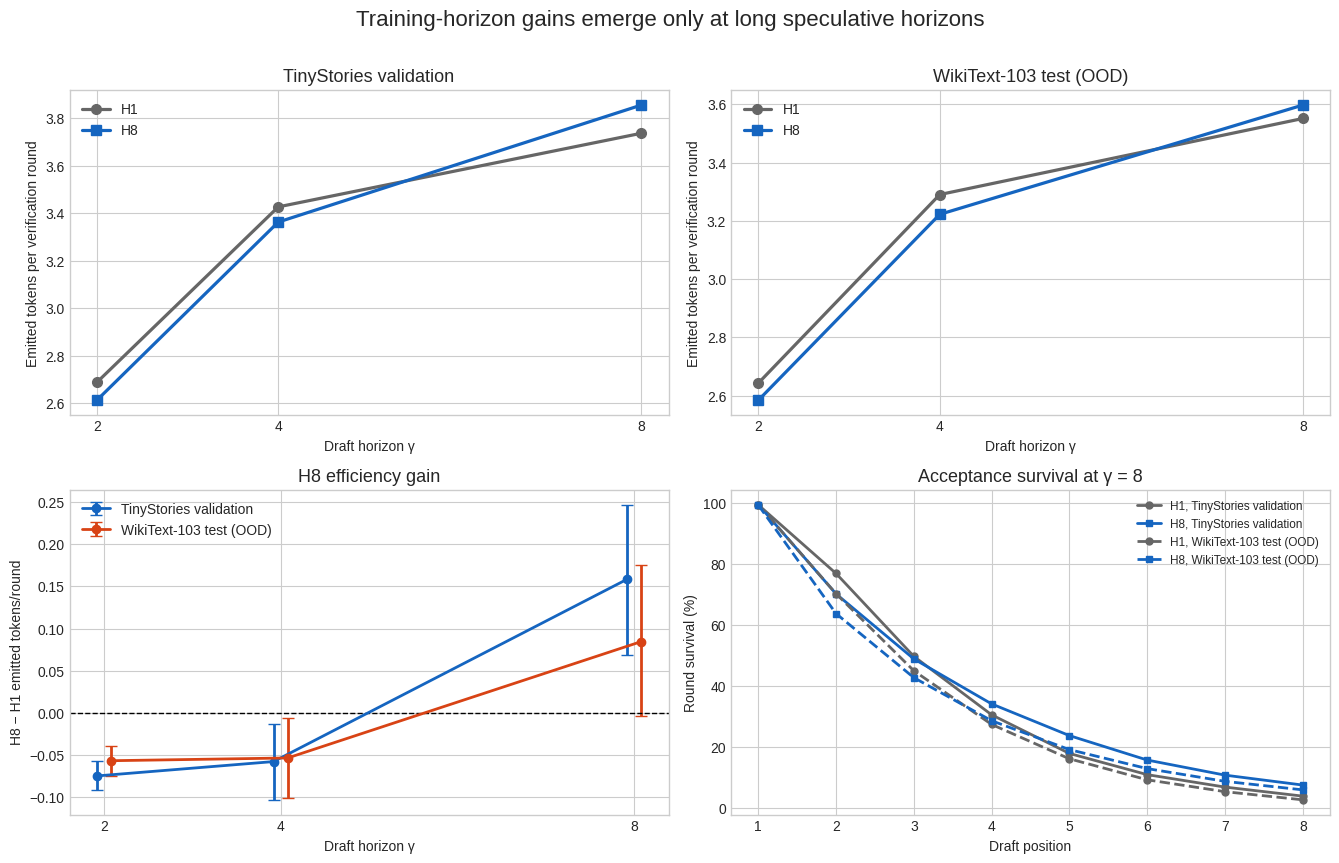


PNG:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/notebook24_h1_h8_acceptance_transfer_seed42.png
Size MB: 0.554

PDF:
/content/drive/MyDrive/ma2288_nextlat/research_v3/results/figures/notebook24_h1_h8_acceptance_transfer_seed42.pdf
Size MB: 0.03

Cell 36 acceptance figure passed.


In [41]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

domains = [
    "TinyStories validation",
    "WikiText-103 test OOD",
]

domain_titles = {
    "TinyStories validation": (
        "TinyStories validation"
    ),
    "WikiText-103 test OOD": (
        "WikiText-103 test (OOD)"
    ),
}

model_colors = {
    "H1": "#666666",
    "H8": "#1565C0",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.5, 8.5),
)

# ------------------------------------------------------------
# Top row: absolute emitted tokens per verification round.
# ------------------------------------------------------------

for column_index, domain_name in enumerate(
    domains
):
    axis = axes[0, column_index]

    domain_df = (
        full_summary_df[
            full_summary_df[
                "domain"
            ] == domain_name
        ]
    )

    for method_name in ["H1", "H8"]:
        method_df = (
            domain_df[
                domain_df["model"]
                == method_name
            ]
            .sort_values("gamma")
        )

        axis.plot(
            method_df["gamma"],
            method_df[
                "emitted_tokens_per_round"
            ],
            marker=(
                "o"
                if method_name == "H1"
                else "s"
            ),
            linewidth=2.3,
            markersize=7,
            label=method_name,
            color=model_colors[
                method_name
            ],
        )

    axis.set_title(
        domain_titles[domain_name],
        fontsize=13,
    )
    axis.set_xlabel(
        "Draft horizon γ"
    )
    axis.set_ylabel(
        "Emitted tokens per verification round"
    )
    axis.set_xticks(FULL_GAMMAS)
    axis.legend(frameon=False)

# ------------------------------------------------------------
# Bottom-left: H8 minus H1 emitted-token improvement with CI.
# ------------------------------------------------------------

axis = axes[1, 0]

emitted_bootstrap_df = (
    acceptance_bootstrap_df[
        acceptance_bootstrap_df[
            "metric"
        ] == "emitted_tokens_improvement"
    ]
)

domain_colors = {
    "TinyStories validation": "#1565C0",
    "WikiText-103 test OOD": "#D84315",
}

domain_offsets = {
    "TinyStories validation": -0.08,
    "WikiText-103 test OOD": 0.08,
}

for domain_name in domains:
    domain_df = (
        emitted_bootstrap_df[
            emitted_bootstrap_df[
                "domain"
            ] == domain_name
        ]
        .sort_values("gamma")
    )

    x_values = (
        domain_df["gamma"].to_numpy()
        + domain_offsets[domain_name]
    )

    point_values = (
        domain_df[
            "point_estimate"
        ].to_numpy()
    )

    lower_errors = (
        point_values
        - domain_df[
            "ci_lower"
        ].to_numpy()
    )

    upper_errors = (
        domain_df[
            "ci_upper"
        ].to_numpy()
        - point_values
    )

    axis.errorbar(
        x_values,
        point_values,
        yerr=[
            lower_errors,
            upper_errors,
        ],
        marker="o",
        capsize=4,
        linewidth=2,
        label=domain_titles[
            domain_name
        ],
        color=domain_colors[
            domain_name
        ],
    )

axis.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axis.set_title(
    "H8 efficiency gain",
    fontsize=13,
)
axis.set_xlabel(
    "Draft horizon γ"
)
axis.set_ylabel(
    "H8 − H1 emitted tokens/round"
)
axis.set_xticks(FULL_GAMMAS)
axis.legend(frameon=False)

# ------------------------------------------------------------
# Bottom-right: survival curves at gamma 8.
# ------------------------------------------------------------

axis = axes[1, 1]

gamma_8_position_df = (
    full_position_summary_df[
        full_position_summary_df[
            "gamma"
        ] == 8
    ]
)

line_styles = {
    "TinyStories validation": "-",
    "WikiText-103 test OOD": "--",
}

for domain_name in domains:
    for method_name in ["H1", "H8"]:
        curve_df = (
            gamma_8_position_df[
                (
                    gamma_8_position_df[
                        "domain"
                    ] == domain_name
                )
                & (
                    gamma_8_position_df[
                        "model"
                    ] == method_name
                )
            ]
            .sort_values("position")
        )

        axis.plot(
            curve_df["position"],
            100.0
            * curve_df[
                "survival_acceptance"
            ],
            marker=(
                "o"
                if method_name == "H1"
                else "s"
            ),
            linestyle=line_styles[
                domain_name
            ],
            linewidth=2,
            markersize=5,
            color=model_colors[
                method_name
            ],
            label=(
                f"{method_name}, "
                f"{domain_titles[domain_name]}"
            ),
        )

axis.set_title(
    "Acceptance survival at γ = 8",
    fontsize=13,
)
axis.set_xlabel(
    "Draft position"
)
axis.set_ylabel(
    "Round survival (%)"
)
axis.set_xticks(
    range(1, 9)
)
axis.legend(
    frameon=False,
    fontsize=8.5,
)

fig.suptitle(
    "Training-horizon gains emerge only at long speculative horizons",
    fontsize=16,
    y=1.01,
)

fig.tight_layout()

ACCEPTANCE_FIGURE_PNG = (
    FIGURES_DIR
    / "notebook24_h1_h8_acceptance_transfer_seed42.png"
)

ACCEPTANCE_FIGURE_PDF = (
    FIGURES_DIR
    / "notebook24_h1_h8_acceptance_transfer_seed42.pdf"
)

fig.savefig(
    ACCEPTANCE_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    ACCEPTANCE_FIGURE_PDF,
    bbox_inches="tight",
)

plt.show()

print("\nPNG:")
print(ACCEPTANCE_FIGURE_PNG)
print(
    "Size MB:",
    round(
        ACCEPTANCE_FIGURE_PNG
        .stat()
        .st_size
        / 1024**2,
        3,
    ),
)

print("\nPDF:")
print(ACCEPTANCE_FIGURE_PDF)
print(
    "Size MB:",
    round(
        ACCEPTANCE_FIGURE_PDF
        .stat()
        .st_size
        / 1024**2,
        3,
    ),
)

print(
    "\nCell 36 acceptance figure passed."
)

In [42]:
tiny_gamma8_decision = (
    acceptance_decision_df[
        (
            acceptance_decision_df[
                "domain"
            ] == "TinyStories validation"
        )
        & (
            acceptance_decision_df[
                "gamma"
            ] == 8
        )
    ].iloc[0]
)

wiki_gamma8_decision = (
    acceptance_decision_df[
        (
            acceptance_decision_df[
                "domain"
            ] == "WikiText-103 test OOD"
        )
        & (
            acceptance_decision_df[
                "gamma"
            ] == 8
        )
    ].iloc[0]
)

notebook24_metadata = {
    "notebook": (
        "24_h1_h8_acceptance_transfer.ipynb"
    ),
    "official_nextlat_commit": (
        OFFICIAL_COMMIT
    ),
    "training_seed": SEED,
    "models": {
        "h1_checkpoint": str(
            H1_CHECKPOINT
        ),
        "h8_checkpoint": str(
            H8_CHECKPOINT
        ),
        "training_steps_each": 5000,
        "training_horizons": [1, 8],
    },
    "protocol": {
        "autonomous_drafting": True,
        "lossless_rejection_correction": True,
        "exact_length_correction": True,
        "temperature": FULL_TEMPERATURE,
        "top_k": FULL_TOP_K,
        "top_p": FULL_TOP_P,
        "draft_horizons": FULL_GAMMAS,
        "prompt_length": FULL_PROMPT_LENGTH,
        "new_tokens_per_decode": (
            FULL_MAX_NEW_TOKENS
        ),
        "prompts_per_domain": (
            FULL_PROMPTS_PER_DOMAIN
        ),
        "trials_per_prompt": (
            FULL_TRIALS_PER_PROMPT
        ),
        "total_decodes": (
            FULL_EXPECTED_DECODES
        ),
        "tiny_stories_eos_tokens_in_prefixes": int(
            (
                tiny_full_prompts
                == tokenizer.eos_token_id
            ).sum()
        ),
    },
    "statistics": {
        "bootstrap_repetitions": (
            BOOTSTRAP_REPETITIONS
        ),
        "tiny_stories_cluster_unit": (
            "packed validation prompt"
        ),
        "wikitext_cluster_unit": (
            "source document"
        ),
        "tiny_stories_clusters": 128,
        "wikitext_clusters": 60,
        "confidence_level": 0.95,
        "multiple_comparison_correction": None,
        "scope": (
            "Evaluation prompt/document variation "
            "conditional on training seed 42"
        ),
    },
    "main_results": {
        "tiny_stories_gamma8": {
            "h1_emitted_tokens_per_round": float(
                tiny_gamma8_decision[
                    "h1_emitted_tokens_per_round"
                ]
            ),
            "h8_emitted_tokens_per_round": float(
                tiny_gamma8_decision[
                    "h8_emitted_tokens_per_round"
                ]
            ),
            "relative_gain_percent": float(
                tiny_gamma8_decision[
                    "relative_emitted_token_gain_percent"
                ]
            ),
            "relative_round_reduction_percent": float(
                tiny_gamma8_decision[
                    "relative_round_reduction_percent"
                ]
            ),
            "decision": str(
                tiny_gamma8_decision[
                    "decision"
                ]
            ),
        },
        "wikitext_gamma8": {
            "h1_emitted_tokens_per_round": float(
                wiki_gamma8_decision[
                    "h1_emitted_tokens_per_round"
                ]
            ),
            "h8_emitted_tokens_per_round": float(
                wiki_gamma8_decision[
                    "h8_emitted_tokens_per_round"
                ]
            ),
            "relative_gain_percent": float(
                wiki_gamma8_decision[
                    "relative_emitted_token_gain_percent"
                ]
            ),
            "relative_round_reduction_percent": float(
                wiki_gamma8_decision[
                    "relative_round_reduction_percent"
                ]
            ),
            "decision": str(
                wiki_gamma8_decision[
                    "decision"
                ]
            ),
        },
    },
    "scientific_conclusion": (
        "Multi-horizon H8 training does not uniformly improve autonomous "
        "speculative acceptance. It is significantly worse at gamma 2 and 4, "
        "but produces a stable in-domain acceptance and verification-efficiency "
        "gain at gamma 8. The gamma-8 OOD point estimate is positive but its "
        "document-cluster confidence interval crosses zero."
    ),
    "mechanistic_interpretation": (
        "H8 weakens early-position acceptance but improves deeper conditional "
        "acceptance. Because speculative decoding stops at the first rejection, "
        "the deeper advantage becomes useful only when the deployment draft "
        "window is sufficiently long."
    ),
    "industrial_interpretation": (
        "At gamma 8, H8 reduces target verification rounds by approximately "
        "3 percent on TinyStories. This is a necessary but insufficient condition "
        "for wall-clock speedup because an eight-token verification pass and "
        "sequential latent drafting have nonzero hardware cost."
    ),
    "limitations": [
        "single training seed",
        "small four-layer model",
        "only four stochastic trials per prompt",
        "TinyStories packed prompts lack source-document identifiers",
        "no multiple-comparison correction",
        "official implementation recomputes full sequences",
        "no KV-cache-aware latency measurement",
        "no batching or serving-runtime integration",
        "no end-to-end wall-clock speedup claim",
    ],
    "decision": (
        "Proceed to a cost-aware gamma benchmark and KV-cache-aware system "
        "prototype before requesting large-model training compute."
    ),
    "artifacts": {
        "trial_results": str(
            FULL_RESULTS_PATH
        ),
        "position_results": str(
            FULL_POSITION_PATH
        ),
        "summary": str(
            FULL_SUMMARY_PATH
        ),
        "comparison": str(
            FULL_COMPARISON_PATH
        ),
        "bootstrap": str(
            BOOTSTRAP_PATH
        ),
        "decision_table": str(
            DECISION_PATH
        ),
        "figure_png": str(
            ACCEPTANCE_FIGURE_PNG
        ),
        "figure_pdf": str(
            ACCEPTANCE_FIGURE_PDF
        ),
    },
}

NOTEBOOK24_METADATA_PATH = (
    METADATA_DIR
    / "notebook24_final_summary_seed42.json"
)

with open(
    NOTEBOOK24_METADATA_PATH,
    "w",
) as file:
    json.dump(
        notebook24_metadata,
        file,
        indent=2,
    )

print("=" * 110)
print("NOTEBOOK 24 FINAL SUMMARY")
print("=" * 110)
print(
    json.dumps(
        notebook24_metadata,
        indent=2,
    )
)

print("\nSaved:")
print(NOTEBOOK24_METADATA_PATH)

print(
    "\nNOTEBOOK 24 COMPLETE"
)

NOTEBOOK 24 FINAL SUMMARY
{
  "notebook": "24_h1_h8_acceptance_transfer.ipynb",
  "official_nextlat_commit": "3770be6009cea2b3c455a9ce7f2ca88b504bb955",
  "training_seed": 42,
  "models": {
    "h1_checkpoint": "/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_pilot_5000_seed42/NextLat_Scaled_5000Step_Seed42-seed42/ckpt_iter_5000_2.0028.pt",
    "h8_checkpoint": "/content/drive/MyDrive/ma2288_nextlat/research_v3/checkpoints/nextlat_h8_pilot_5000_seed42/NextLat_H8_5000Step_Seed42-seed42/ckpt_iter_5000_2.3431.pt",
    "training_steps_each": 5000,
    "training_horizons": [
      1,
      8
    ]
  },
  "protocol": {
    "autonomous_drafting": true,
    "lossless_rejection_correction": true,
    "exact_length_correction": true,
    "temperature": 1.0,
    "top_k": null,
    "top_p": null,
    "draft_horizons": [
      2,
      4,
      8
    ],
    "prompt_length": 32,
    "new_tokens_per_decode": 32,
    "prompts_per_domain": 128,
    "trials_per_prompt": 4,
    "tot

In [43]:
import zipfile
from pathlib import Path

GITHUB_BUNDLE_PATH = (
    V3_DIR
    / "notebook24_github_bundle.zip"
)

github_artifacts = {
    # Figures
    ACCEPTANCE_FIGURE_PNG:
        "results_v3/figures/"
        "notebook24_h1_h8_acceptance_transfer_seed42.png",

    ACCEPTANCE_FIGURE_PDF:
        "results_v3/figures/"
        "notebook24_h1_h8_acceptance_transfer_seed42.pdf",

    # Compact summaries
    FULL_SUMMARY_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_acceptance_summary_seed42.csv",

    FULL_COMPARISON_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_acceptance_comparison_seed42.csv",

    FULL_POSITION_SUMMARY_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_position_summary_seed42.csv",

    BOOTSTRAP_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_acceptance_cluster_bootstrap_seed42.csv",

    DECISION_PATH:
        "results_v3/tables/"
        "notebook24_acceptance_decision_seed42.csv",

    # Raw and paired evaluation results
    FULL_RESULTS_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_acceptance_trials_seed42.csv",

    FULL_POSITION_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_acceptance_positions_seed42.csv",

    PAIRED_TRIAL_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_paired_trials_seed42.csv",

    PAIRED_PROMPT_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_paired_prompts_seed42.csv",

    PAIRED_CLUSTER_PATH:
        "results_v3/tables/"
        "notebook24_h1_h8_paired_clusters_seed42.csv",

    FULL_WIKITEXT_SELECTION:
        "results_v3/tables/"
        "notebook24_wikitext_prompt_selection_seed42.csv",

    # Metadata
    NOTEBOOK24_METADATA_PATH:
        "results_v3/metadata/"
        "notebook24_final_summary_seed42.json",
}

print("=" * 120)
print("NOTEBOOK 24 GITHUB BUNDLE")
print("=" * 120)

with zipfile.ZipFile(
    GITHUB_BUNDLE_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for source_path, archive_path in (
        github_artifacts.items()
    ):
        source_path = Path(source_path)

        assert source_path.exists(), (
            f"Missing artifact: {source_path}"
        )

        archive.write(
            source_path,
            arcname=archive_path,
        )

        print(
            f"{archive_path:<95} "
            f"{source_path.stat().st_size / 1024**2:.3f} MB"
        )

print("\nBundle:")
print(GITHUB_BUNDLE_PATH)
print(
    "Bundle size MB:",
    round(
        GITHUB_BUNDLE_PATH.stat().st_size
        / 1024**2,
        3,
    ),
)

print(
    "\nThe prompt tensor cache is intentionally "
    "excluded from GitHub."
)
print(
    "Cell 38 GitHub bundle passed."
)

NOTEBOOK 24 GITHUB BUNDLE
results_v3/figures/notebook24_h1_h8_acceptance_transfer_seed42.png                              0.554 MB
results_v3/figures/notebook24_h1_h8_acceptance_transfer_seed42.pdf                              0.030 MB
results_v3/tables/notebook24_h1_h8_acceptance_summary_seed42.csv                                0.002 MB
results_v3/tables/notebook24_h1_h8_acceptance_comparison_seed42.csv                             0.003 MB
results_v3/tables/notebook24_h1_h8_position_summary_seed42.csv                                  0.005 MB
results_v3/tables/notebook24_h1_h8_acceptance_cluster_bootstrap_seed42.csv                      0.005 MB
results_v3/tables/notebook24_acceptance_decision_seed42.csv                                     0.001 MB
results_v3/tables/notebook24_h1_h8_acceptance_trials_seed42.csv                                 0.778 MB
results_v3/tables/notebook24_h1_h8_acceptance_positions_seed42.csv                              1.377 MB
results_v3/tables/notebook24_